# Fashion MNIST：神經網路圖像分類專案

本專案使用 PyTorch 對 [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) 資料集進行圖像分類。從最基礎的全連接網路出發，逐步發展至深層 CNN，並延伸至 KMNIST 與 PneumoniaMNIST 的遷移學習實驗。

**資料集：** 70,000 張 28×28 灰階圖像，共 10 個服飾類別

| 標籤 | 類別 |
|------|------|
| 0 | T恤/上衣 |
| 1 | 長褲 |
| 2 | 套頭衫 |
| 3 | 洋裝 |
| 4 | 外套 |
| 5 | 涼鞋 |
| 6 | 襯衫 |
| 7 | 運動鞋 |
| 8 | 包包 |
| 9 | 踝靴 |

In [ ]:
# Codegrade Tag ResearchConsent
# Do *not* remove the tag above
# Redefine the variable below to False if you do not want to participate in research
RESEARCH_CONSENT = True

## 1. 資料載入與前處理

透過 `torchvision` 下載 Fashion MNIST 資料集，並套用標準化正規化（mean=0.5、std=0.5）。原始 60,000 張訓練圖像以固定隨機種子（seed=42）切分為 50,000 張訓練子集與 10,000 張驗證子集，確保結果可重現。

In [2]:
# Do not change the contents of this cell

import torch
import torchvision
import torchvision.transforms as transforms
import torch.utils


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,], std=[0.5,])
])

train_set = torchvision.datasets.FashionMNIST(root='.', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='.', train=False, download=True, transform=transform)

train_subset, val_subset = torch.utils.data.random_split(train_set, [5/6, 1/6], torch.Generator().manual_seed(42))

100.0%
100.0%
100.0%
100.0%


## 2. 資料集視覺化

從訓練集抽取 10 張圖像，以 2×5 的網格方式顯示。像素值從正規化範圍 [−1, 1] 還原至 [0, 1] 以便正確顯示，每張圖像標註對應的數字類別編號。

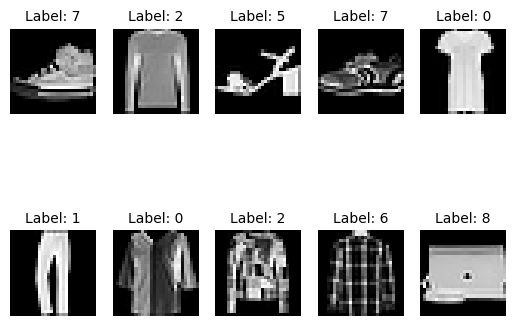

In [3]:
# Codegrade Tag Question1
# Do *not* remove the tag above

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

train_loader = DataLoader(train_subset, batch_size = 64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size = 64, shuffle=True)
test_loader = DataLoader(test_set, batch_size = 64, shuffle=True)

images, labels = next(iter(train_loader))

#select first 10 images and class label
images = images[:10]
labels = labels[:10]

images = (images + 1)/2 #rescale to [0,1]

#plotting 
fig, ax = plt.subplots(2, 5)
ax = ax.flatten()

for i in range(len(images)):
    ax[i].imshow(images[i].squeeze(), cmap="gray")
    ax[i].set_title(f"Label: {labels[i].item()}", fontsize=10)
    ax[i].axis('off')
    
plt.show()

## 3. 模型架構一 — SimpleNN

以單隱藏層的多層感知器（MLP）作為基準線，建立效能底線。模型將 28×28 的輸入展平為 784 維向量，經一個隱藏層與 ReLU 激活函數後，輸出 10 類別的 logits。

### 3.1 網路定義

定義 `SimpleNN(input_size, hidden_size, output_size)`，使用 `nn.Sequential` 堆疊單層 `Linear → ReLU → Linear`。

In [4]:
# Codegrade Tag Question2a
# Do *not* remove the tag above

import torch.nn as nn
import torch

class SimpleNN(nn.Module):
    """
    A simple neural network with one fully connected layer.
    """
    def __init__(self, input_size, hidden_size, output_size):
        """
        Construct the layers.
        Parameters:
        - input_size: the size of the input images (flattened!)
        - hidden_size: number of neurons in the hidden layer
        - output_size: number of output neurons (i.e., the number of class labels)
        """
        super().__init__()
        
        self.flatten = nn.Flatten() #initialize the flatten function
        self.linear_network = nn.Sequential( #makking the NN 
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x):
        """
        Evaluate the network for the input x.
        """
        x = self.flatten(x) #flatten the picture
        logits = self.linear_network(x)
        return logits


#crete model
simple_nn = SimpleNN(input_size = 28*28, hidden_size = 64, output_size = 10)


### 3.2 單輪訓練函式 — `train_one_epoch`

實作一個 epoch 的隨機梯度下降：前向傳播 → 計算交叉熵損失 → 反向傳播 → 透過優化器更新權重。回傳所有批次的平均損失與準確率。

In [5]:
# Codegrade Tag Question2b
# Do *not* remove the tag above

import torch.optim as optim

def train_one_epoch(model, loader, loss_fn, optimizer):
    """
    Train the model using the data from loader for one epoch.
    
    Parameters:
    - model: nn.Model, the model to train
    - loader: Dataloader, the training dataset
    - loss: the loss function
    - optimizer: optim.Optimizer, the optimizer to use
    
    Return value:
    - A tuple (mean_loss,accuracy) where mean_loss is the average loss over the 
    epoch and accuracy is the training accuracy (correct classifications of the 
    training set / number of items in the training set)
    """
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        output = model(images)
        loss = loss_fn(output, labels)

        #backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        #accumulate loss
        total_loss += loss.item() * images.size(0)

        #compute predictions and accuracy
        prediction = output.argmax(dim=1)
        correct += (prediction == labels).sum().item()
        total += labels.size(0)
    
    #compute mean loss and accuracy
    mean_loss = total_loss/ total
    accuracy = correct / total

    return mean_loss, accuracy




### 3.3 評估函式

在不更新權重的情況下評估模型。以 `model.eval()` 搭配 `torch.no_grad()` 關閉梯度計算，回傳平均損失與準確率。

In [6]:
# Codegrade Tag Question2c
# Do *not* remove the tag above

def evaluate(model, loader, loss_fn):
    """
    Evaluates the model against the dataset provided by loader with respect to the loss function.
    
    Parameters:
    - model: nn.Model, the model to train
    - loader: Dataloader, the training dataset
    - loss: the loss function
    
    Return value:
    - A tuple (mean_loss,accuracy) where mean_loss is the average loss over the dataset and
    accuracy is the validation/test accuracy (correct classifications / number of items in the set)
    """
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            output = model(images)
            #accumulate loss
            loss = loss_fn(output, labels).item()
            total_loss += loss * labels.size(0)

            #Compute predictions and accuracy
            prediction = output.argmax(dim=1)
            correct += (prediction == labels).sum().item()
            total += labels.size(0)
        
    #compute mean loss and accuracy
    mean_loss = total_loss/ total
    accuracy = correct / total

    return mean_loss, accuracy


### 3.4 完整訓練流程

以 Adam 優化器（lr=0.0001）與交叉熵損失協調多輪訓練。每個 epoch 結束後在驗證集上評估，並記錄訓練/驗證的損失與準確率，供後續分析使用。

In [7]:
# Codegrade Tag Question2d
# Do *not* remove the tag above

def train(model, train_loader, val_loader, num_epochs, learning_rate = 0.0001):
    """
    Trains the model using Adam optimizer and Cross Entropy Loss for the given 
    number of epochs against the training set.
    After each epoch, evaluates the model against the validation set.
    
    Returns a 4-tuple (train_losses,train_accuracies,val_losses,val_accuracies)
    """

    #define optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()

    #initialize lists
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    #loop throug number of epochs
    for epoch in range(num_epochs):
        #get the train loss and accuracy from the train_one_epoch function and train the model for one epoch
        train_loss, train_accuracy = train_one_epoch(model, train_loader, loss_fn, optimizer)

        #evaluate the model and get the valuation loss and accuracy
        val_loss, val_accuracy = evaluate(model, val_loader, loss_fn)

        #store the values in the return lists
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
    
    return train_losses, train_accuracies, val_losses, val_accuracies

### 3.5 訓練 SimpleNN（10 個 Epoch）

訓練基準模型 10 個 epoch 並繪製學習曲線。訓練完成的權重儲存至 `simple_nn.pt` 以便後續評估。

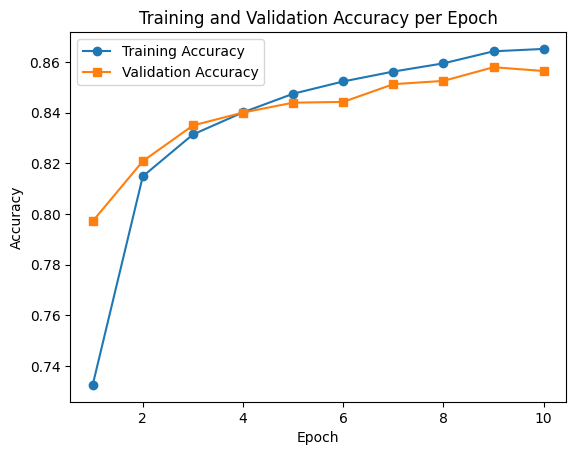

In [8]:
# Codegrade Tag Question2e
# Do *not* remove the tag above

num_epochs = 10

#train the model
train_losses, train_accuracies, val_losses, val_accuracies = train(simple_nn, train_loader, val_loader, num_epochs)

#save the model
torch.save(simple_nn.state_dict(), "simple_nn.pt")

#plot the graph of the training and validation accuracy
epochs = range(1, num_epochs + 1)
fig, ax = plt.subplots()
plt.plot(epochs, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='s')
plt.title('Training and Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### 3.6 測試集評估 — SimpleNN

載入儲存的 checkpoint，在 10,000 張測試圖像上評估模型，取得最終基準準確率。

In [9]:
# Codegrade Tag Question2f
# Do *not* remove the tag above

simple_nn = SimpleNN(input_size = 28*28, hidden_size = 64, output_size = 10)

simple_nn.load_state_dict(torch.load("simple_nn.pt"))

loss_fn = nn.CrossEntropyLoss()

test_loss, test_accuracy_simple = evaluate(simple_nn, test_loader, loss_fn)

print(test_accuracy_simple * 100)

84.96000000000001


## 4. 模型架構二 — TwoLayerNN

加入第二個隱藏層並搭配 Dropout 正規化以降低過擬合。網路架構為 `784 → 512 → 256 → 10`，每個隱藏層激活後加入 Dropout(p=0.2)。

### 4.1 網路定義

定義 `TwoLayerNN(input_size, hidden_sizes, output_size, dropout)`，包含兩個全連接隱藏層，各自後接 Dropout 與 ReLU。

In [10]:
# Codegrade Tag Question3a
# Do *not* remove the tag above

class TwoLayerNN(nn.Module):
    """
    A simple neural network with two fully connected hidden layers, 
    each of which is followed by a dropout layer.
        """
    def __init__(self, input_size, hidden_sizes, output_size, dropout_prob):
        """
        Constructor.        
        Parameters:
        - input_size: integer, the flattened vector size of inputs
        - hidden_sizes: a tuple of two integers, the sizes of the two hidden layers
        - output_size: number of outputs (number of classes)
        - dropout_prob: float, probability parameter for the dropout layers
        """
        super().__init__()

         # split hidden sizes
        hidden1, hidden2 = hidden_sizes

        #flatten and make the nettrowk 
        self.flatten = nn.Flatten()
        self.linear_network = nn.Sequential(
            nn.Linear(input_size, hidden1), #input to the first hidden layer
            nn.Dropout(dropout_prob), #dropout layer after firts hidden layer
            nn.ReLU(), #first hidden layer
            nn.Linear(hidden1, hidden2), # hidden layer to dropout layer
            nn.Dropout(dropout_prob), #droput layer after second hidden layer
            nn.ReLU(), #second hidden layer
            nn.Linear(hidden2, output_size) #second hidden layer to output layer
        )
    
    def forward(self, x):
        """
        Evaluates the network for the given argument x.
        """
        x = self.flatten(x) #flatten the picture
        logits = self.linear_network(x)
        return logits

two_layer_nn = TwoLayerNN(input_size = 28*28, hidden_sizes = (512,256), output_size = 10, dropout_prob = 0.2) #making an instance of the model


### 4.2 訓練 TwoLayerNN（10 個 Epoch）

訓練並儲存雙層網路，繪製學習曲線以便與 SimpleNN 基準進行比較。

89.268


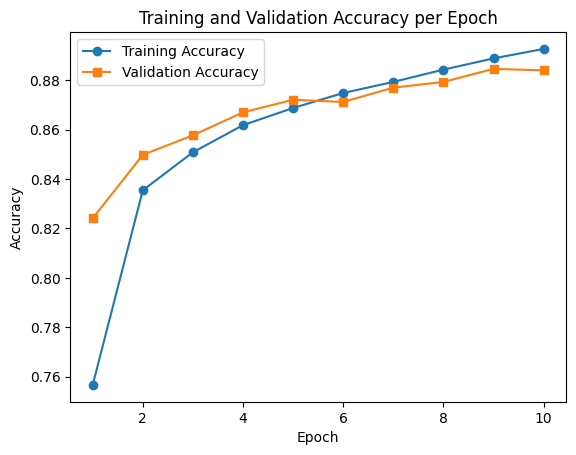

In [11]:
# Codegrade Tag Question3b
# Do *not* remove the tag above
num_epochs = 10

#train the model
train_losses, train_accuracies, val_losses, val_accuracies = train(two_layer_nn, train_loader, val_loader, num_epochs)

#save the model
torch.save(two_layer_nn.state_dict(), "two_layer_nn.pt")

print(train_accuracies[9] * 100) #print the final training accuracy

epochs = range(1, num_epochs + 1)
fig, ax = plt.subplots()
plt.plot(epochs, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='s')
plt.title('Training and Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### 4.3 測試集評估 — TwoLayerNN

載入 `two_layer_nn.pt` 並回報最終測試準確率。

In [12]:
# Codegrade Tag Question3c
# Do *not* remove the tag above
two_layer_nn = TwoLayerNN(input_size = 28*28, hidden_sizes = (512,256), output_size = 10, dropout_prob = 0.2) #making an instance of the model

two_layer_nn.load_state_dict(torch.load("two_layer_nn.pt"))

loss_fn = nn.CrossEntropyLoss()

test_loss, test_accuracy_two_layer = evaluate(two_layer_nn, test_loader, loss_fn)

print(test_accuracy_two_layer * 100) #print the test accuracy


87.68


## 5. 模型架構三 — 卷積神經網路（CNN）

利用圖像的空間局部性設計完整 CNN。三個卷積區塊（`Conv2d → BatchNorm2d → ReLU → MaxPool2d`）逐層提取特徵，通道數從 32 → 64 → 128，最後接三層全連接層並搭配 Dropout(0.5)。

### 5.1 網路定義

定義可配置的 `CNN` 類別，支援自訂通道寬度、卷積核大小、填充、池化與全連接層維度。透過對卷積區塊進行一次假前向傳播，自動計算展平特徵的尺寸，使架構與輸入解析度解耦。

In [13]:
# Codegrade Tag Question4a
# Do *not* remove the tag above

class CNN(nn.Module):
    """
    A convolutional neural network with three convolutional layers (each contains a batch normalization, 
    relu activation, followed by max pooling),
    flattening, followed by three fully connected layers (the first two followed by dropouts)
    """
    def __init__(self, in_sizes, in_channels, conv1_channels, conv2_channels, conv3_channels, 
                 kernel_size, padding, pool_size, fc1_size, fc2_size, out_size, dropout_probability):
        """
        Parameters:
        - in_sizes: (width,height) tuple for image dimensions
        - in_channels: integer, number of input channels (1 for greyscale)
        - conv1_channels, conv2_channels, conv3_channels: integer, output channels for the convolutional layer
        - kernel_size: integer, shared kernel size for all convolutional layers
        - padding: integer, shared padding for all convolutional layers
        - fc1_size, fc2_size: integer, number of neurons in the fully connected layers
        - out_size: integer, output layer size (number of classes)
        - dropout_probability: float, shared dropout probability for fully connected layers
        """
        super().__init__()

        #convolution layers
        self.convolution_layers = nn.Sequential(
            #conv layer 1
            nn.Conv2d(in_channels, conv1_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv1_channels),
            nn.ReLU(),
            nn.MaxPool2d(pool_size),

            #conv layer 2
            nn.Conv2d(conv1_channels, conv2_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv2_channels),
            nn.ReLU(),
            nn.MaxPool2d(pool_size),

            #conv layer 3
            nn.Conv2d(conv2_channels, conv3_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv3_channels),
            nn.ReLU(),
            nn.MaxPool2d(pool_size)
        )

         # compute flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, in_sizes[0], in_sizes[1])
            out = self.convolution_layers(dummy)
            self.flat_features = out.numel()  # total features after last conv block
        
        #fully connected layers
        self.linear_network = nn.Sequential(
            nn.Linear(self.flat_features, fc1_size),
            nn.ReLU(),
            nn.Dropout(dropout_probability),

            nn.Linear(fc1_size, fc2_size),
            nn.ReLU(),
            nn.Dropout(dropout_probability),

            nn.Linear(fc2_size, out_size)
        )

    def forward(self, x):
        """
        Evaluates the network
        """
        x = self.convolution_layers(x)
        x = torch.flatten(x, 1)
        x = self.linear_network(x)
        return x

cnn = CNN(in_sizes = (28,28), in_channels = 1, conv1_channels = 32, conv2_channels = 64, conv3_channels = 128, 
          kernel_size = 3, padding = 1, pool_size = 2, fc1_size = 256, fc2_size = 128, out_size = 10, dropout_probability = 0.5) #making an instance of the model

### 5.2 訓練 CNN（10 個 Epoch）

訓練並儲存 CNN，監控驗證準確率以偵測過擬合跡象。

92.944


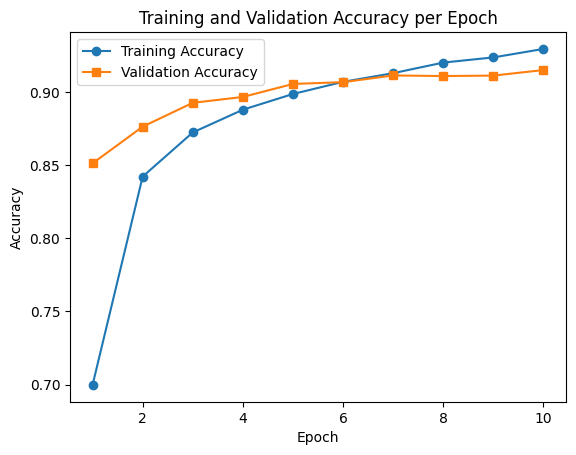

In [14]:
# Codegrade Tag Question4b
# Do *not* remove the tag above

num_epochs = 10

#train the model
train_losses, train_accuracies, val_losses, val_accuracies = train(cnn, train_loader, val_loader, num_epochs)

#save the model
torch.save(cnn.state_dict(), "cnn.pt")

print(train_accuracies[9] * 100) #print the final training accuracy

epochs = range(1, num_epochs + 1)
fig, ax = plt.subplots()
plt.plot(epochs, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', marker='s')
plt.title('Training and Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 5.3 測試集評估 — CNN

載入 `cnn.pt` 並記錄最終測試準確率，供三模型比較分析使用。

In [15]:
# Codegrade Tag Question4c
# Do *not* remove the tag above
cnn = CNN(in_sizes = (28,28), in_channels = 1, conv1_channels = 32, conv2_channels = 64, conv3_channels = 128, 
          kernel_size = 3, padding = 1, pool_size = 2, fc1_size = 256, fc2_size = 128, out_size = 10, dropout_probability = 0.5) #making an instance of the model

cnn.load_state_dict(torch.load("cnn.pt"))

loss_fn = nn.CrossEntropyLoss()

test_loss, test_accuracy_cnn = evaluate(cnn, test_loader, loss_fn)

print(test_accuracy_cnn * 100) #print the test accuracy


90.96


## 6. 模型比較與討論

三種架構在容量與訓練成本上呈現明顯梯度：

| 模型 | 容量 | 訓練速度 | 預期準確率 |
|------|------|----------|------------|
| SimpleNN | 低 | 最快 | 基準線 |
| TwoLayerNN | 中 | 快 | 中等提升 |
| CNN | 高 | 最慢 | 最佳 |

效益隨複雜度增加而遞減：CNN 帶來最大的準確率提升，但計算成本最高，且訓練與驗證準確率之間出現差距，顯示輕微過擬合。

*Write your answer here*
The simple NN had the worst performance but also it was clearly the fastest, in the midle we had the two layer NN that was in the middle and the most accurate waws the CNN but that was more slow to train and therfore more expencive. The simple NN was not overfitting mutch after 10 epochs as seen by the validasion accuracies that for the most part cept increasing, on the other hand the two layer NN was not shown to overfit where the validasion accuracy increesed throug all the eopchs. The CNN is showing a clear indication of overfitting where the validation accuracy is not improving after a few epochs. 

We can observe similarities to the law of diminishing returns in neural networks in the way that after a while the training does not improve by much but it gets more and more expencive. therefore doing to advanced NN or train them for manny epochs will not be worth it because of the cost.

## 7. 完整訓練與評估 Pipeline

一個完整自包含的程式區塊，重新匯入所有相依套件、重新定義三個模型類別，並對每個架構執行完整的訓練 → 驗證 → 測試流程，方便從頭重現所有結果。

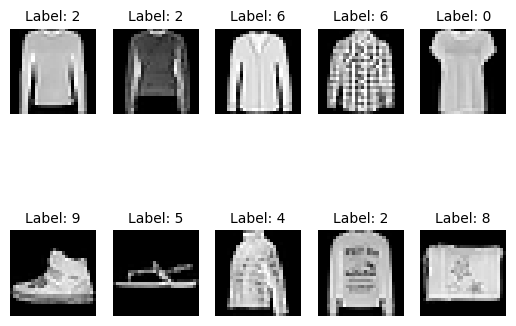

--- Training SimpleNN ---


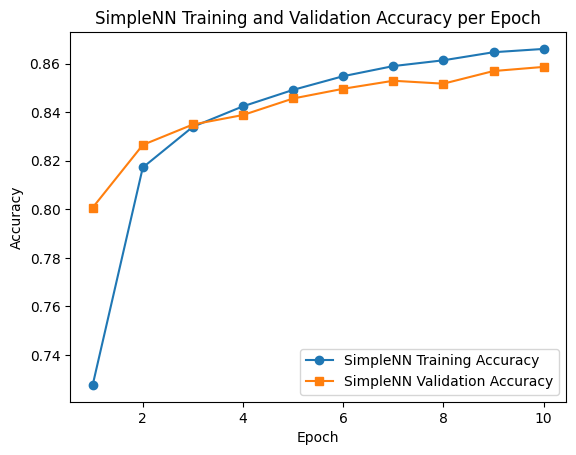

SimpleNN Test Accuracy: 85.14%
------------------------------
--- Training TwoLayerNN ---
TwoLayerNN Final Training Accuracy: 89.14%


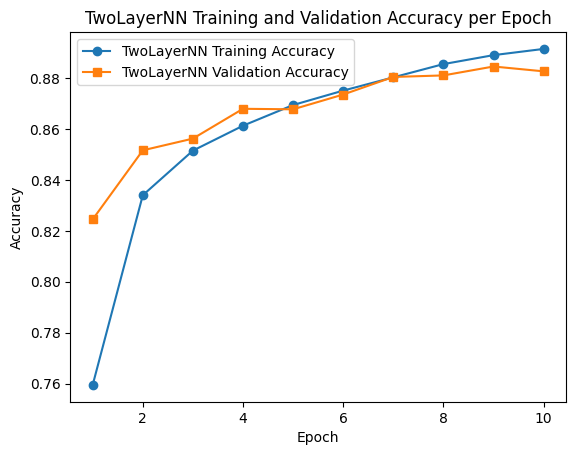

TwoLayerNN Test Accuracy: 87.72%
------------------------------
--- Training CNN ---
CNN Final Training Accuracy: 94.62%


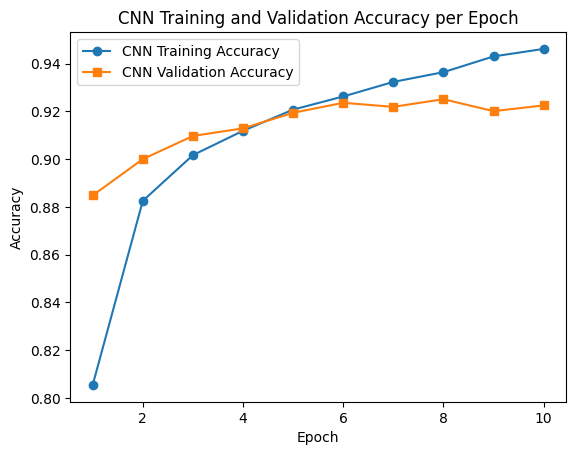

CNN Test Accuracy: 91.93%
------------------------------


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

# --- 1. 資料準備與處理 ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,], std=[0.5,])
])

train_set = torchvision.datasets.FashionMNIST(root='.', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='.', train=False, download=True, transform=transform)

# 分割訓練集為訓練子集和驗證子集
train_subset, val_subset = torch.utils.data.random_split(
    train_set, [5/6, 1/6], torch.Generator().manual_seed(42)
)

# 創建 DataLoaders
batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True)

# 視覺化資料
images, labels = next(iter(train_loader))
images = images[:10]
labels = labels[:10]
images = (images + 1)/2 # rescale to [0,1] for plotting

fig, ax = plt.subplots(2, 5)
ax = ax.flatten()
for i in range(len(images)):
    ax[i].imshow(images[i].squeeze(), cmap="gray")
    ax[i].set_title(f"Label: {labels[i].item()}", fontsize=10)
    ax[i].axis('off')
plt.show()

# --- 2. 訓練和評估函數定義 ---

def train_one_epoch(model, loader, loss_fn, optimizer):
    """
    Train the model using the data from loader for one epoch.
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        output = model(images)
        loss = loss_fn(output, labels)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Accumulate loss and compute accuracy
        total_loss += loss.item() * images.size(0)
        prediction = output.argmax(dim=1)
        correct += (prediction == labels).sum().item()
        total += labels.size(0)

    mean_loss = total_loss / total
    accuracy = correct / total
    return mean_loss, accuracy

def evaluate(model, loader, loss_fn):
    """
    Evaluates the model against the dataset provided by loader.
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            output = model(images)
            # Accumulate loss
            loss = loss_fn(output, labels).item()
            total_loss += loss * labels.size(0)

            # Compute predictions and accuracy
            prediction = output.argmax(dim=1)
            correct += (prediction == labels).sum().item()
            total += labels.size(0)

    mean_loss = total_loss / total
    accuracy = correct / total
    return mean_loss, accuracy

def train(model, train_loader, val_loader, num_epochs, learning_rate=0.0001):
    """
    Trains the model and evaluates it on the validation set after each epoch.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_accuracy = evaluate(model, val_loader, loss_fn)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

    return train_losses, train_accuracies, val_losses, val_accuracies

# --- 3. 模型定義 ---

class SimpleNN(nn.Module):
    """A simple neural network with one fully connected layer."""
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_network(x)
        return logits

class TwoLayerNN(nn.Module):
    """A simple neural network with two fully connected hidden layers, each followed by a dropout layer."""
    def __init__(self, input_size, hidden_sizes, output_size, dropout_prob):
        super().__init__()
        hidden1, hidden2 = hidden_sizes
        self.flatten = nn.Flatten()
        self.linear_network = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.Dropout(dropout_prob),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.Dropout(dropout_prob),
            nn.ReLU(),
            nn.Linear(hidden2, output_size)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_network(x)
        return logits

class CNN(nn.Module):
    """A convolutional neural network with three convolutional blocks and three fully connected layers."""
    def __init__(self, in_sizes, in_channels, conv1_channels, conv2_channels, conv3_channels,
                 kernel_size, padding, pool_size, fc1_size, fc2_size, out_size, dropout_probability):
        super().__init__()

        self.convolution_layers = nn.Sequential(
            # conv layer 1
            nn.Conv2d(in_channels, conv1_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv1_channels),
            nn.ReLU(),
            nn.MaxPool2d(pool_size),

            # conv layer 2
            nn.Conv2d(conv1_channels, conv2_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv2_channels),
            nn.ReLU(),
            nn.MaxPool2d(pool_size),

            # conv layer 3
            nn.Conv2d(conv2_channels, conv3_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(conv3_channels),
            nn.ReLU(),
            nn.MaxPool2d(pool_size)
        )

        # compute flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, in_sizes[0], in_sizes[1])
            out = self.convolution_layers(dummy)
            self.flat_features = out.numel()

        # fully connected layers
        self.linear_network = nn.Sequential(
            nn.Linear(self.flat_features, fc1_size),
            nn.ReLU(),
            nn.Dropout(dropout_probability),

            nn.Linear(fc1_size, fc2_size),
            nn.ReLU(),
            nn.Dropout(dropout_probability),

            nn.Linear(fc2_size, out_size)
        )

    def forward(self, x):
        x = self.convolution_layers(x)
        x = torch.flatten(x, 1)
        x = self.linear_network(x)
        return x

# --- 4. 訓練與評估流程 (SimpleNN) ---
num_epochs = 10
input_size = 28 * 28
output_size = 10

print("--- Training SimpleNN ---")
simple_nn = SimpleNN(input_size=input_size, hidden_size=64, output_size=output_size)
train_losses_simple, train_accuracies_simple, val_losses_simple, val_accuracies_simple = train(
    simple_nn, train_loader, val_loader, num_epochs
)
torch.save(simple_nn.state_dict(), "simple_nn.pt")

# Plotting
epochs = range(1, num_epochs + 1)
fig, ax = plt.subplots()
plt.plot(epochs, train_accuracies_simple, label='SimpleNN Training Accuracy', marker='o')
plt.plot(epochs, val_accuracies_simple, label='SimpleNN Validation Accuracy', marker='s')
plt.title('SimpleNN Training and Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Test evaluation
simple_nn_loaded = SimpleNN(input_size=input_size, hidden_size=64, output_size=output_size)
simple_nn_loaded.load_state_dict(torch.load("simple_nn.pt"))
loss_fn = nn.CrossEntropyLoss()
_, test_accuracy_simple = evaluate(simple_nn_loaded, test_loader, loss_fn)
print(f"SimpleNN Test Accuracy: {test_accuracy_simple * 100:.2f}%")
print("-" * 30)

# --- 5. 訓練與評估流程 (TwoLayerNN) ---
print("--- Training TwoLayerNN ---")
hidden_sizes_two_layer = (512, 256)
dropout_prob_two_layer = 0.2
two_layer_nn = TwoLayerNN(
    input_size=input_size,
    hidden_sizes=hidden_sizes_two_layer,
    output_size=output_size,
    dropout_prob=dropout_prob_two_layer
)
train_losses_two_layer, train_accuracies_two_layer, val_losses_two_layer, val_accuracies_two_layer = train(
    two_layer_nn, train_loader, val_loader, num_epochs
)
torch.save(two_layer_nn.state_dict(), "two_layer_nn.pt")
print(f"TwoLayerNN Final Training Accuracy: {train_accuracies_two_layer[num_epochs-1] * 100:.2f}%")

# Plotting
fig, ax = plt.subplots()
plt.plot(epochs, train_accuracies_two_layer, label='TwoLayerNN Training Accuracy', marker='o')
plt.plot(epochs, val_accuracies_two_layer, label='TwoLayerNN Validation Accuracy', marker='s')
plt.title('TwoLayerNN Training and Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Test evaluation
two_layer_nn_loaded = TwoLayerNN(
    input_size=input_size,
    hidden_sizes=hidden_sizes_two_layer,
    output_size=output_size,
    dropout_prob=dropout_prob_two_layer
)
two_layer_nn_loaded.load_state_dict(torch.load("two_layer_nn.pt"))
_, test_accuracy_two_layer = evaluate(two_layer_nn_loaded, test_loader, loss_fn)
print(f"TwoLayerNN Test Accuracy: {test_accuracy_two_layer * 100:.2f}%")
print("-" * 30)

# --- 6. 訓練與評估流程 (CNN) ---
print("--- Training CNN ---")
cnn = CNN(
    in_sizes=(28, 28), in_channels=1,
    conv1_channels=32, conv2_channels=64, conv3_channels=128,
    kernel_size=3, padding=1, pool_size=2,
    fc1_size=256, fc2_size=128, out_size=output_size,
    dropout_probability=0.5
)
train_losses_cnn, train_accuracies_cnn, val_losses_cnn, val_accuracies_cnn = train(
    cnn, train_loader, val_loader, num_epochs, learning_rate=0.001  # Increased LR for CNN as is common
)
torch.save(cnn.state_dict(), "cnn.pt")
print(f"CNN Final Training Accuracy: {train_accuracies_cnn[num_epochs-1] * 100:.2f}%")

# Plotting
fig, ax = plt.subplots()
plt.plot(epochs, train_accuracies_cnn, label='CNN Training Accuracy', marker='o')
plt.plot(epochs, val_accuracies_cnn, label='CNN Validation Accuracy', marker='s')
plt.title('CNN Training and Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Test evaluation
cnn_loaded = CNN(
    in_sizes=(28, 28), in_channels=1,
    conv1_channels=32, conv2_channels=64, conv3_channels=128,
    kernel_size=3, padding=1, pool_size=2,
    fc1_size=256, fc2_size=128, out_size=output_size,
    dropout_probability=0.5
)
cnn_loaded.load_state_dict(torch.load("cnn.pt"))
_, test_accuracy_cnn = evaluate(cnn_loaded, test_loader, loss_fn)
print(f"CNN Test Accuracy: {test_accuracy_cnn * 100:.2f}%")
print("-" * 30)

## 8. CNN 錯誤分析 — 混淆矩陣

使用 Seaborn 熱力圖視覺化 CNN 在測試集上的混淆矩陣，並輸出完整的逐類別 `classification_report`（精確率、召回率、F1 分數）。此分析揭示哪些服飾類別最容易被錯誤分類。

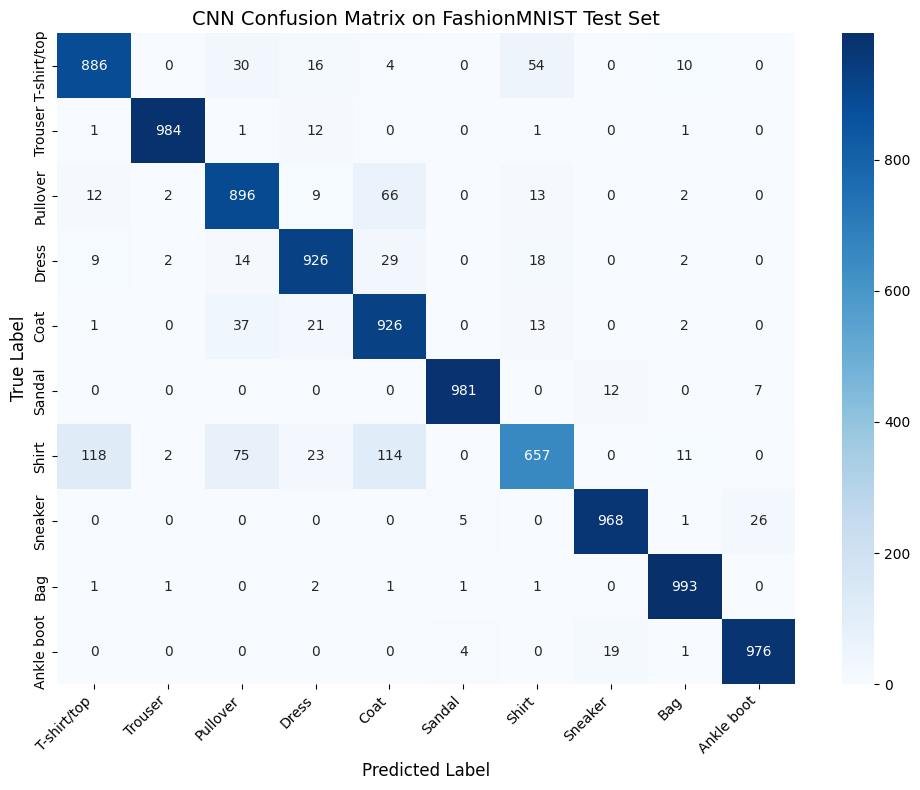


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.85      0.90      0.87      1000
       Dress       0.92      0.93      0.92      1000
        Coat       0.81      0.93      0.87      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.87      0.66      0.75      1000
     Sneaker       0.97      0.97      0.97      1000
         Bag       0.97      0.99      0.98      1000
  Ankle boot       0.97      0.98      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [2]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# FashionMNIST 類別名稱
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# --- 載入訓練好的 CNN 模型 ---
cnn_loaded = CNN(
    in_sizes=(28, 28), in_channels=1,
    conv1_channels=32, conv2_channels=64, conv3_channels=128,
    kernel_size=3, padding=1, pool_size=2,
    fc1_size=256, fc2_size=128, out_size=10,
    dropout_probability=0.5
)
cnn_loaded.load_state_dict(torch.load("cnn.pt"))
cnn_loaded.eval()

# --- 收集所有預測結果 ---
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = cnn_loaded(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# --- 繪製混淆矩陣 ---
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('CNN Confusion Matrix on FashionMNIST Test Set', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 印出分類報告 ---
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

### 8.1 錯誤分類樣本視覺化

以 4×5 網格顯示前 20 張被錯誤分類的圖像。每張圖像標題以紅色字體標示真實標籤與預測標籤，方便觀察系統性混淆模式。

Total misclassified samples: 807 / 10000
Error rate: 8.07%


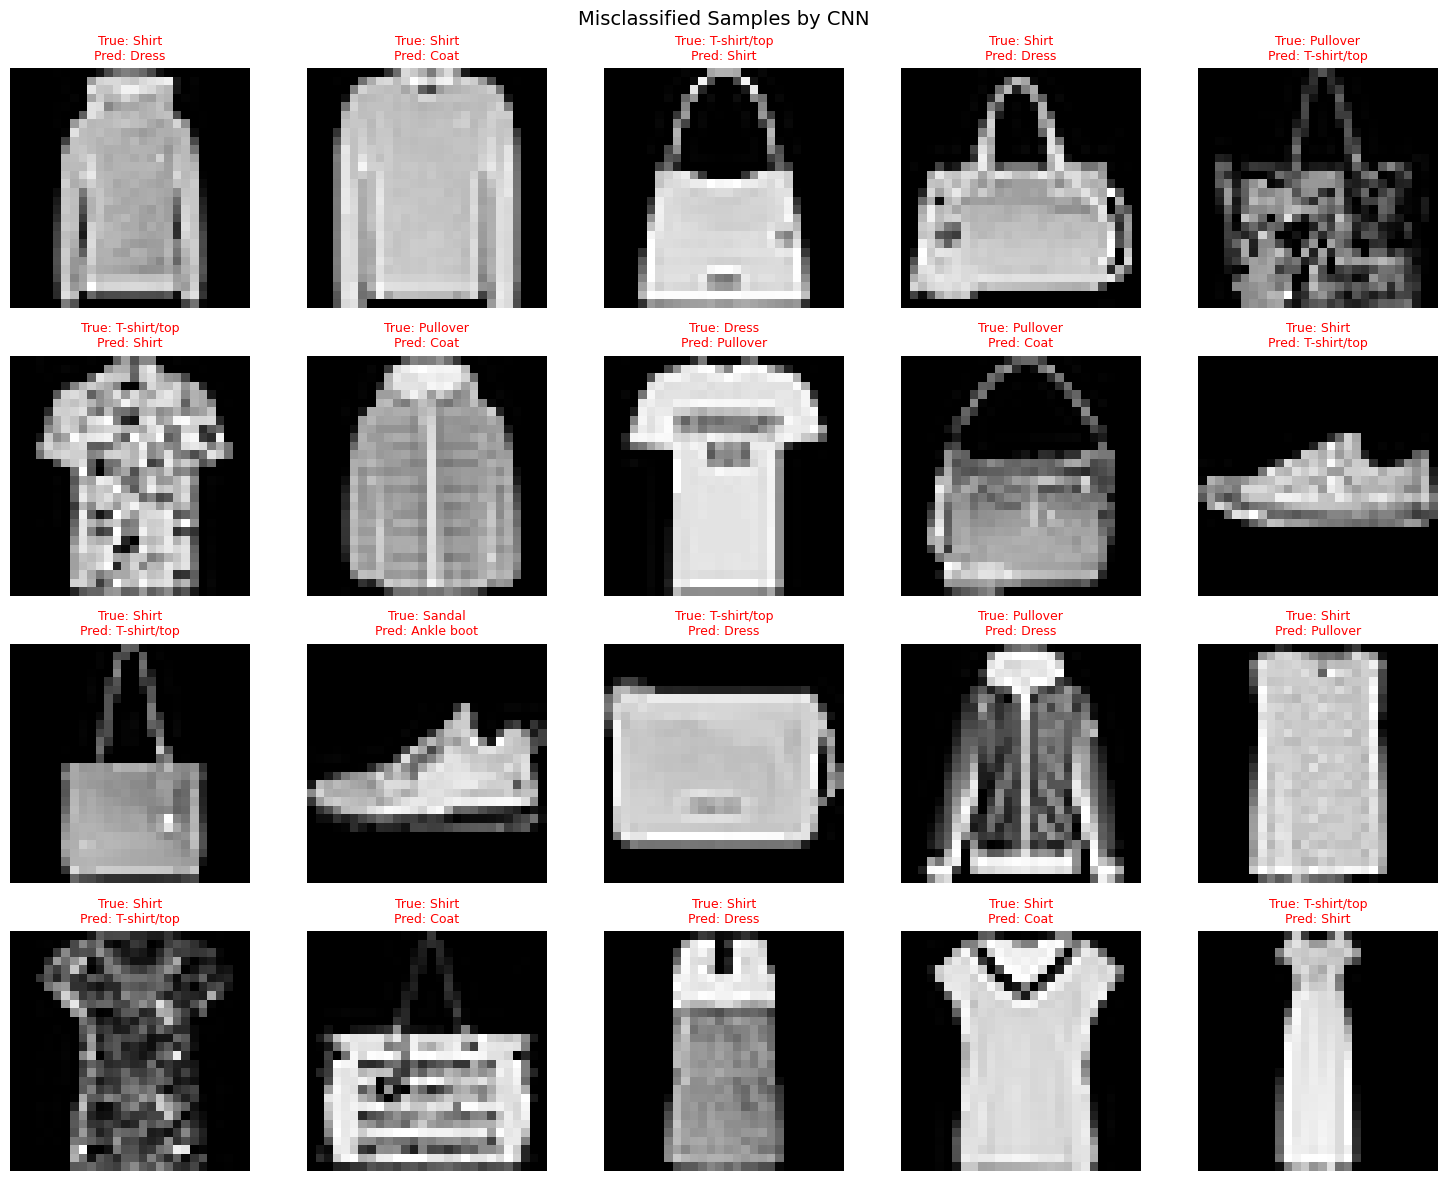

In [3]:
# --- 收集錯誤樣本 ---
wrong_indices = np.where(all_preds != all_labels)[0]
print(f"Total misclassified samples: {len(wrong_indices)} / {len(all_labels)}")
print(f"Error rate: {len(wrong_indices) / len(all_labels) * 100:.2f}%")

# --- 收集測試集所有圖片（用於視覺化）---
all_images = []
for images, _ in test_loader:
    all_images.append(images)
all_images = torch.cat(all_images, dim=0)

# --- 視覺化前 20 個錯誤樣本 ---
num_display = 20
selected = wrong_indices[:num_display]

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, idx in enumerate(selected):
    img = (all_images[idx].squeeze() + 1) / 2  # 還原至 [0,1]
    axes[i].imshow(img, cmap='gray')
    true_label = class_names[all_labels[idx]]
    pred_label = class_names[all_preds[idx]]
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}",
                      fontsize=9, color='red')
    axes[i].axis('off')

plt.suptitle('Misclassified Samples by CNN', fontsize=14)
plt.tight_layout()
plt.show()

### 8.2 最常混淆的類別組合

從混淆矩陣中找出 Top-5 最容易互相混淆的類別組合，並視覺化混淆程度最高的一對類別的代表樣本。這類混淆通常發生在外觀相似的類別之間，例如 Shirt 與 T-shirt/top。

Top-5 最常混淆的類別對：
True Class           Predicted As         Count
-------------------------------------------------------
Shirt                T-shirt/top          118
Shirt                Coat                 114
Shirt                Pullover             75
Pullover             Coat                 66
T-shirt/top          Shirt                54


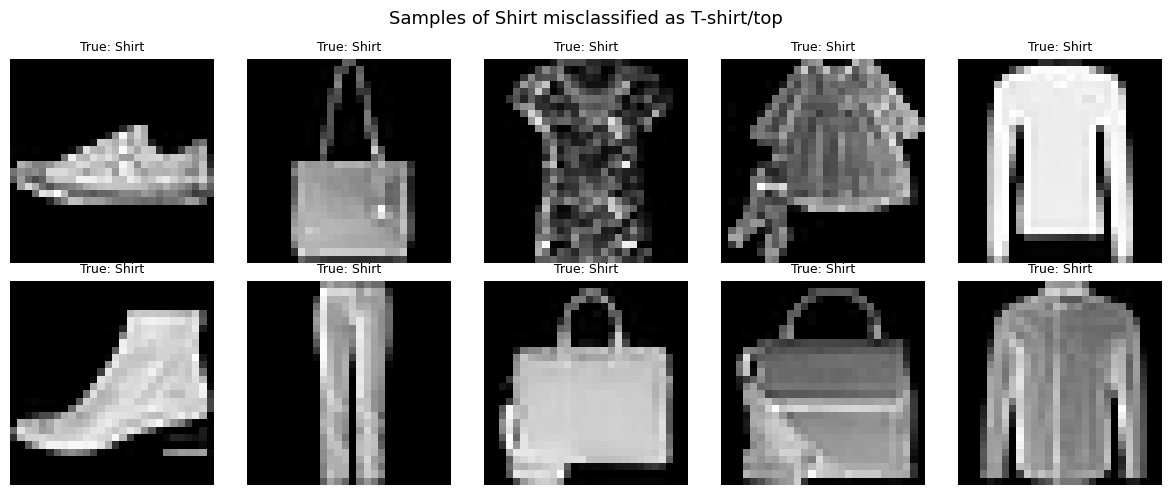

In [4]:
# --- 找出最常混淆的類別對 ---
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# 找出 Top-5 混淆對
top_confusions = []
for _ in range(5):
    idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
    true_cls, pred_cls = idx
    count = cm_no_diag[true_cls, pred_cls]
    top_confusions.append((true_cls, pred_cls, count))
    cm_no_diag[true_cls, pred_cls] = 0

print("Top-5 最常混淆的類別對：")
print(f"{'True Class':<20} {'Predicted As':<20} {'Count'}")
print("-" * 55)
for true_cls, pred_cls, count in top_confusions:
    print(f"{class_names[true_cls]:<20} {class_names[pred_cls]:<20} {count}")

# --- 針對最常混淆的類別對視覺化 ---
top_true, top_pred, _ = top_confusions[0]
confused_mask = (all_labels == top_true) & (all_preds == top_pred)
confused_indices = np.where(confused_mask)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i in range(min(10, len(confused_indices))):
    idx = confused_indices[i]
    img = (all_images[idx].squeeze() + 1) / 2
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {class_names[top_true]}", fontsize=9)
    axes[i].axis('off')

plt.suptitle(f'Samples of {class_names[top_true]} misclassified as {class_names[top_pred]}',
             fontsize=13)
plt.tight_layout()
plt.show()

## 9. 遷移學習 — KMNIST

測試 Fashion MNIST CNN 對結構相似但視覺風格截然不同的領域之泛化能力：[KMNIST](https://github.com/rois-codh/kmnist) 包含 70,000 張手寫日文平假名字元圖像，共 10 個類別。

本節從 Hugging Face 下載 KMNIST，封裝為 PyTorch `Dataset`，並視覺化樣本圖像與對應字元名稱以確認資料正確載入。


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached datasets-4.6.1-py3-none-any.whl.metadata (19 kB)
  Using cached pyarrow-23.0.1-cp313-cp313-win_amd64.whl.metadata (3.1 kB)
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.6.0-cp313-cp313-win_amd64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.18-py313-none-any.whl.metadata (7.2 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp313-cp313-win_amd64.whl.metadata (21 kB)
  Using cached propcache-0.4.1-cp313-cp313-win_amd64.whl.metadata (14 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached datasets-4.6.1-py3-none-any.whl (520 kB)
Using cached dill-0.4.0-py3-none-any.whl (119 kB)
   ---------------------------------------- 0.0/596.3 kB ? et

c:\Users\tonykuo\PycharmProjects\JupyterProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\Users\tonykuo\PycharmProjects\JupyterProject\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\tonykuo\.cache\huggingface\hub\datasets--tanganke--kmnist. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 742249.59 examples/s]


Train size: 60,000  |  Test size: 10,000


C:\Users\tonykuo\AppData\Local\Temp\ipykernel_45684\2420524803.py:74: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tonykuo\AppData\Local\Temp\ipykernel_45684\2420524803.py:74: UserWarning: Glyph 12414 (\N{HIRAGANA LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tonykuo\AppData\Local\Temp\ipykernel_45684\2420524803.py:74: UserWarning: Glyph 12365 (\N{HIRAGANA LETTER KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tonykuo\AppData\Local\Temp\ipykernel_45684\2420524803.py:74: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tonykuo\AppData\Local\Temp\ipykernel_45684\2420524803.py:74: UserWarning: Glyph 12399 (\N{HIRAGANA LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\tonykuo\PycharmProjects\JupyterProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 123

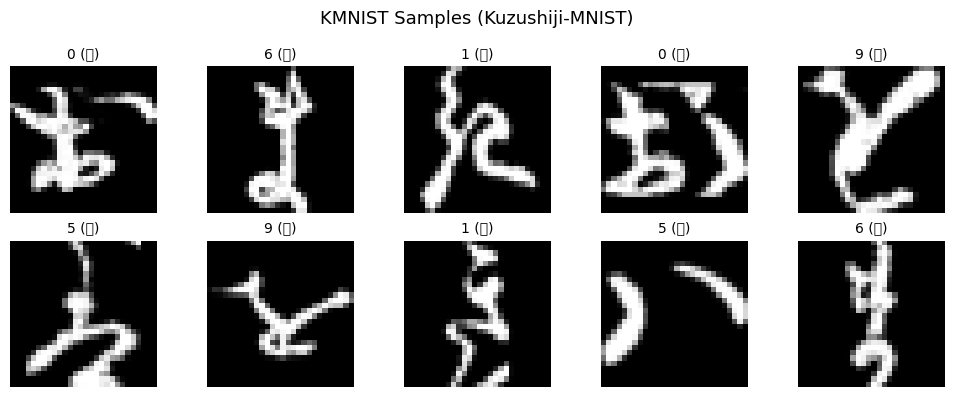

In [11]:

!pip install datasets

from datasets import load_dataset as hf_load_dataset
from PIL import Image as PILImage

# --- HuggingFace Dataset → PyTorch Dataset 橋接器 ---
class HFDatasetWrapper(torch.utils.data.Dataset):
    """
    將 Hugging Face Dataset 包裝為 PyTorch Dataset。
    處理 PIL Image（灰階）的 transform 套用。
    """
    def __init__(self, hf_dataset, transform=None):
        self.dataset   = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item  = self.dataset[idx]
        image = item['image']          # PIL Image
        label = item['label']

        # 確保為灰階模式（KMNIST 本身為灰階，保險起見轉換）
        if image.mode != 'L':
            image = image.convert('L')

        if self.transform:
            image = self.transform(image)

        return image, label


# --- 載入 KMNIST（from Hugging Face）---
kmnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print("Downloading KMNIST from Hugging Face...")
hf_kmnist_train = hf_load_dataset("tanganke/kmnist", split="train")
hf_kmnist_test  = hf_load_dataset("tanganke/kmnist", split="test")

kmnist_train_full = HFDatasetWrapper(hf_kmnist_train, transform=kmnist_transform)
kmnist_test_set   = HFDatasetWrapper(hf_kmnist_test,  transform=kmnist_transform)

print(f"Train size: {len(kmnist_train_full):,}  |  Test size: {len(kmnist_test_set):,}")

# 5:1 拆分訓練 / 驗證
kmnist_train_subset, kmnist_val_subset = torch.utils.data.random_split(
    kmnist_train_full, [5/6, 1/6],
    torch.Generator().manual_seed(42)
)

kmnist_train_loader = DataLoader(kmnist_train_subset, batch_size=64, shuffle=True)
kmnist_val_loader   = DataLoader(kmnist_val_subset,   batch_size=64, shuffle=False)
kmnist_test_loader  = DataLoader(kmnist_test_set,     batch_size=64, shuffle=False)

# 視覺化 KMNIST 樣本
kmnist_class_names = ['お', 'き', 'す', 'つ', 'な', 'は', 'ま', 'や', 'れ', 'を']

kmnist_images, kmnist_labels = next(iter(kmnist_train_loader))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()
for i in range(10):
    img = (kmnist_images[i].squeeze() + 1) / 2
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(
        f"{kmnist_labels[i].item()} ({kmnist_class_names[kmnist_labels[i].item()]})",
        fontsize=10
    )
    axes[i].axis('off')
plt.suptitle('KMNIST Samples (Kuzushiji-MNIST)', fontsize=13)
plt.tight_layout()
plt.show()

### 9.1 遷移學習模型 — `FineTuneCNN`

載入預訓練的 `cnn.pt` 權重，並採用選擇性凍結策略：

- **凍結：** 卷積區塊 1 & 2（低階邊緣與紋理特徵偵測器，具跨領域通用性）
- **可訓練：** 卷積區塊 3 與全部全連接層（高階語意特徵，需針對目標領域調整）

此策略在複用底層通用特徵的同時，大幅減少需要更新的參數量。

In [18]:
class FineTuneCNN(nn.Module):
    """
    部分解凍遷移學習模型：
    - Conv Block 1 & 2：凍結（保留通用低階特徵）
    - Conv Block 3：解凍（微調高階特徵以適應 KMNIST）
    - FC 分類頭：重新初始化
    """
    def __init__(self, pretrained_cnn, num_classes=10, dropout_probability=0.3):
        super().__init__()

        # 完整複製卷積層
        self.convolution_layers = pretrained_cnn.convolution_layers

        # 先全部凍結
        for param in self.convolution_layers.parameters():
            param.requires_grad = False

        # 每個卷積塊佔 4 個子層 (Conv2d, BatchNorm2d, ReLU, MaxPool2d)
        # Block3 = indices 8, 9, 10, 11
        for param in self.convolution_layers[8:].parameters():
            param.requires_grad = True

        self.flat_features = pretrained_cnn.flat_features

        # 新的全連接分類頭
        self.linear_network = nn.Sequential(
            nn.Linear(self.flat_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.convolution_layers(x)
        x = torch.flatten(x, 1)
        x = self.linear_network(x)
        return x


# --- 建立 Fine-tune 模型 ---
pretrained_cnn = CNN(
    in_sizes=(28, 28), in_channels=1,
    conv1_channels=32, conv2_channels=64, conv3_channels=128,
    kernel_size=3, padding=1, pool_size=2,
    fc1_size=256, fc2_size=128, out_size=10,
    dropout_probability=0.5
)
pretrained_cnn.load_state_dict(torch.load("cnn.pt"))

finetune_model = FineTuneCNN(pretrained_cnn, num_classes=10, dropout_probability=0.3)

# 確認參數分配
frozen_params    = sum(p.numel() for p in finetune_model.parameters() if not p.requires_grad)
trainable_params = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)
total_params     = frozen_params + trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Frozen (Block1+2):    {frozen_params:,}")
print(f"Trainable (Block3+FC):{trainable_params:,}")
print(f"Trainable ratio:      {trainable_params / total_params * 100:.1f}%")

Total parameters:     422,474
Frozen (Block1+2):    19,008
Trainable (Block3+FC):403,466
Trainable ratio:      95.5%


### 9.2 實驗一 — 完整 KMNIST 資料：遷移 vs. 從頭訓練

在完整 KMNIST 訓練集上比較四種訓練策略：

| 策略 | 凍結層 | 可訓練層 |
|------|--------|----------|
| 完全凍結遷移 | 區塊 1–3 + FC | 無 |
| 微調 V1 | 區塊 1–2 | 區塊 3 + FC |
| 微調 V2 | 區塊 1–2 | 區塊 3 + FC + 早停 |
| 從頭訓練 CNN | 無 | 全部 |

針對每種策略繪製準確率與損失的學習曲線。

Epoch  1 | Train Acc: 91.00% | Val Acc: 96.78% | Val Loss: 0.1055
Epoch  2 | Train Acc: 97.20% | Val Acc: 96.94% | Val Loss: 0.1014
Epoch  3 | Train Acc: 98.14% | Val Acc: 97.75% | Val Loss: 0.0771
Epoch  4 | Train Acc: 98.62% | Val Acc: 97.72% | Val Loss: 0.0856
Epoch  5 | Train Acc: 98.86% | Val Acc: 98.19% | Val Loss: 0.0711
Epoch  6 | Train Acc: 98.91% | Val Acc: 98.09% | Val Loss: 0.0709
Epoch  7 | Train Acc: 99.20% | Val Acc: 98.02% | Val Loss: 0.0755
Epoch  8 | Train Acc: 99.20% | Val Acc: 97.66% | Val Loss: 0.0890
Epoch  9 | Train Acc: 99.29% | Val Acc: 98.19% | Val Loss: 0.0728
Epoch 10 | Train Acc: 99.32% | Val Acc: 98.03% | Val Loss: 0.0844 → LR: 1.00e-04 → 5.00e-05
Epoch 11 | Train Acc: 99.65% | Val Acc: 98.32% | Val Loss: 0.0650
Epoch 12 | Train Acc: 99.79% | Val Acc: 98.47% | Val Loss: 0.0690
Epoch 13 | Train Acc: 99.79% | Val Acc: 98.47% | Val Loss: 0.0656
Epoch 14 | Train Acc: 99.76% | Val Acc: 98.25% | Val Loss: 0.0694
Epoch 15 | Train Acc: 99.77% | Val Acc: 98.43% | V

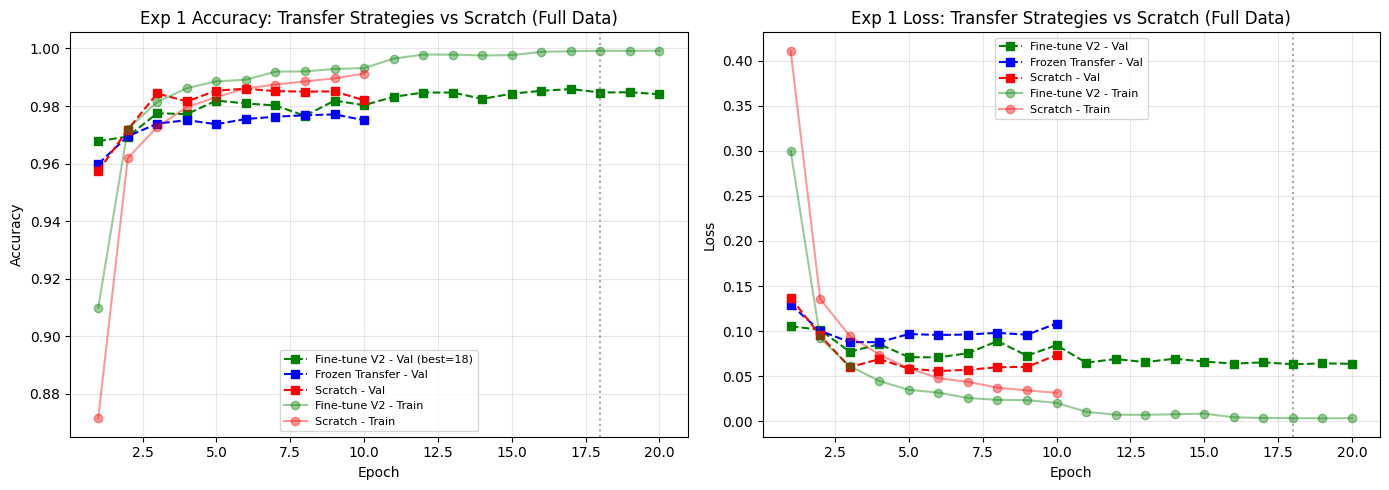

In [23]:
# ========================================================
# 實驗一：全資料量對比（整理版）
# ========================================================

# --- 重新訓練所有模型（若已有結果可直接載入）---

# Frozen Transfer
pretrained_cnn.load_state_dict(torch.load("cnn.pt"))
transfer_model = TransferCNN(pretrained_cnn, num_classes=10, dropout_probability=0.3)
tl_train_losses, tl_train_accs, tl_val_losses, tl_val_accs = train(
    transfer_model, kmnist_train_loader, kmnist_val_loader,
    num_epochs=10, learning_rate=0.001
)
torch.save(transfer_model.state_dict(), "transfer_cnn_kmnist.pt")

# Fine-tune V1
pretrained_cnn.load_state_dict(torch.load("cnn.pt"))
finetune_model_v1 = FineTuneCNN(pretrained_cnn, num_classes=10, dropout_probability=0.3)
ft1_train_losses, ft1_train_accs, ft1_val_losses, ft1_val_accs = train(
    finetune_model_v1, kmnist_train_loader, kmnist_val_loader,
    num_epochs=10, learning_rate=0.001
)

# Fine-tune V2（已有結果，直接載入）
pretrained_cnn.load_state_dict(torch.load("cnn.pt"))
finetune_model_v2 = FineTuneCNN(pretrained_cnn, num_classes=10, dropout_probability=0.3)
ft2_train_losses, ft2_train_accs, ft2_val_losses, ft2_val_accs, best_ep = train_finetune_v2(
    finetune_model_v2, kmnist_train_loader, kmnist_val_loader, num_epochs=20
)

# Scratch CNN
scratch_cnn = CNN(
    in_sizes=(28, 28), in_channels=1,
    conv1_channels=32, conv2_channels=64, conv3_channels=128,
    kernel_size=3, padding=1, pool_size=2,
    fc1_size=256, fc2_size=128, out_size=10,
    dropout_probability=0.5
)
scratch_train_losses, scratch_train_accs, scratch_val_losses, scratch_val_accs = train(
    scratch_cnn, kmnist_train_loader, kmnist_val_loader,
    num_epochs=10, learning_rate=0.001
)

# --- 測試集評估 ---
loss_fn = nn.CrossEntropyLoss()
_, acc_frozen    = evaluate(transfer_model,    kmnist_test_loader, loss_fn)
_, acc_ft1       = evaluate(finetune_model_v1, kmnist_test_loader, loss_fn)
_, acc_ft2       = evaluate(finetune_model_v2, kmnist_test_loader, loss_fn)
_, acc_scratch   = evaluate(scratch_cnn,       kmnist_test_loader, loss_fn)

print(f"\n{'='*55}")
print(f"【實驗一：全資料量】")
print(f"{'Model':<35} {'Test Acc':>10}")
print(f"{'-'*55}")
print(f"{'Transfer (fully frozen)':<35} {acc_frozen*100:>9.2f}%")
print(f"{'Fine-tune V1 (no regularize)':<35} {acc_ft1*100:>9.2f}%")
print(f"{'Fine-tune V2 (best epoch=' + str(best_ep) + ')':<35} {acc_ft2*100:>9.2f}%")
print(f"{'From-Scratch CNN':<35} {acc_scratch*100:>9.2f}%")
print(f"{'='*55}")

# --- 學習曲線（三方對比）---
epochs_ft2   = range(1, len(ft2_train_accs) + 1)
epochs_10    = range(1, 11)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ft2, ft2_val_accs,       'g--s', label=f'Fine-tune V2 - Val (best={best_ep})')
ax1.plot(epochs_10,  tl_val_accs,        'b--s', label='Frozen Transfer - Val')
ax1.plot(epochs_10,  scratch_val_accs,   'r--s', label='Scratch - Val')
ax1.plot(epochs_ft2, ft2_train_accs,     'g-o',  alpha=0.4, label='Fine-tune V2 - Train')
ax1.plot(epochs_10,  scratch_train_accs, 'r-o',  alpha=0.4, label='Scratch - Train')
ax1.axvline(x=best_ep, color='gray', linestyle=':', alpha=0.7)
ax1.set_title('Exp 1 Accuracy: Transfer Strategies vs Scratch (Full Data)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ft2, ft2_val_losses,       'g--s', label='Fine-tune V2 - Val')
ax2.plot(epochs_10,  tl_val_losses,        'b--s', label='Frozen Transfer - Val')
ax2.plot(epochs_10,  scratch_val_losses,   'r--s', label='Scratch - Val')
ax2.plot(epochs_ft2, ft2_train_losses,     'g-o',  alpha=0.4, label='Fine-tune V2 - Train')
ax2.plot(epochs_10,  scratch_train_losses, 'r-o',  alpha=0.4, label='Scratch - Train')
ax2.axvline(x=best_ep, color='gray', linestyle=':', alpha=0.7)
ax2.set_title('Exp 1 Loss: Transfer Strategies vs Scratch (Full Data)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.3 實驗二 — 進階訓練：早停與學習率調度

實作 `train_with_earlystop`，加入以下機制：
- **早停（Early Stopping）**：防止過擬合
- **ReduceLROnPlateau**：自適應學習率衰減
- **Weight Decay**：L2 正規化

以此設定進行兩項比較實驗：
1. 微調 V2 vs. 從頭訓練（完整 KMNIST）
2. 微調 V2 vs. 從頭訓練（PneumoniaMNIST 醫療影像領域）

--- Fine-tune V2 | KMNIST Full Data ---
Epoch  1 | Train Acc: 92.50% | Val Acc:   97.75% | Val Loss: 0.0793
Epoch  2 | Train Acc: 97.90% | Val Acc:   97.86% | Val Loss: 0.0716
Epoch  3 | Train Acc: 98.58% | Val Acc:   98.40% | Val Loss: 0.0561
Epoch  4 | Train Acc: 98.97% | Val Acc:   98.17% | Val Loss: 0.0663
Epoch  5 | Train Acc: 99.09% | Val Acc:   98.56% | Val Loss: 0.0517
Epoch  6 | Train Acc: 99.28% | Val Acc:   98.04% | Val Loss: 0.0793
Epoch  7 | Train Acc: 99.34% | Val Acc:   98.24% | Val Loss: 0.0660
Epoch  8 | Train Acc: 99.25% | Val Acc:   98.14% | Val Loss: 0.0735
Epoch  9 | Train Acc: 99.43% | Val Acc:   98.48% | Val Loss: 0.0649 → LR: 1.00e-03 → 5.00e-04
Epoch 10 | Train Acc: 99.81% | Val Acc:   98.77% | Val Loss: 0.0550

Early stopping at epoch 10. Best epoch: 5
Best epoch: 5  |  Best val loss: 0.0517

--- Scratch CNN | KMNIST Full Data ---
Epoch  1 | Train Acc: 86.49% | Val Acc:   96.62% | Val Loss: 0.1142
Epoch  2 | Train Acc: 95.71% | Val Acc:   97.68% | Val Loss: 0.

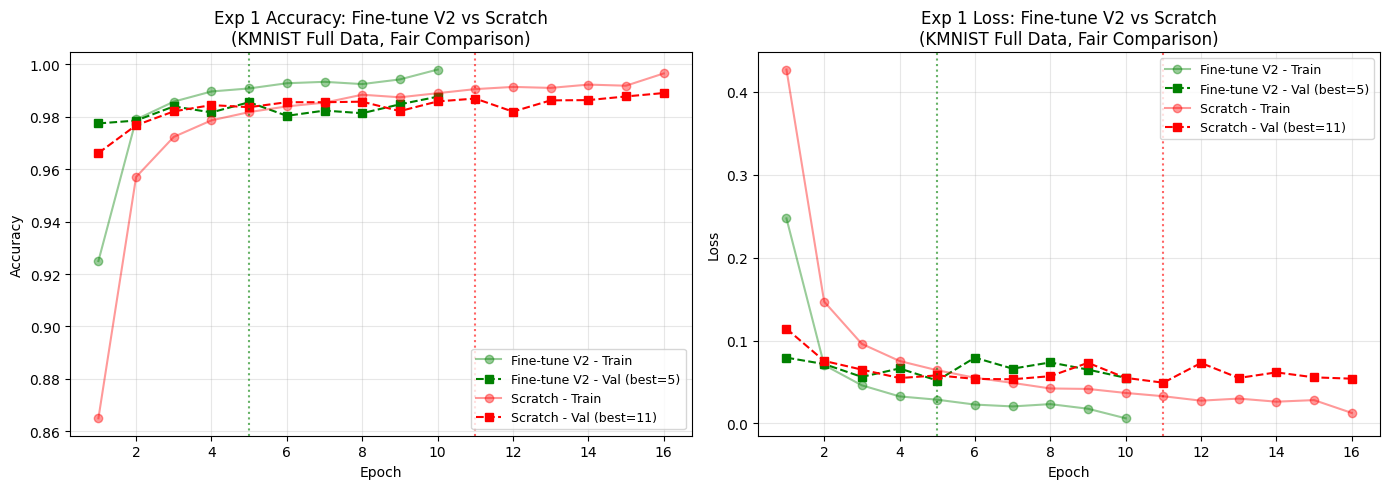


--- Fine-tune V2 | PneumoniaMNIST ---


NameError: name 'pneumonia_train_loader' is not defined

In [25]:
# ========================================================
# 函數定義 + 實驗一 + 實驗二（完整版）
# ========================================================

def train_with_earlystop(model, train_loader, val_loader, num_epochs,
                         learning_rate=0.001, weight_decay=1e-4,
                         patience=5, min_delta=1e-3,
                         save_path="best_model.pt"):
    """
    通用 Early Stopping 訓練迴圈
    - Weight decay 正則化
    - ReduceLROnPlateau 自動降低學習率
    - Early stopping + min_delta
    """
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),
                           lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    best_val_loss    = float('inf')
    best_epoch       = 0
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            output = model(images)
            loss   = loss_fn(output, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item() * images.size(0)
            correct    += (output.argmax(dim=1) == labels).sum().item()
            total      += labels.size(0)
        train_losses.append(total_loss / total)
        train_accs.append(correct / total)

        val_loss, val_acc = evaluate(model, val_loader, loss_fn)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        lr_msg = f" → LR: {old_lr:.2e} → {new_lr:.2e}" if new_lr != old_lr else ""

        print(f"Epoch {epoch+1:2d} | "
              f"Train Acc: {train_accs[-1]*100:.2f}% | "
              f"Val Acc:   {val_accs[-1]*100:.2f}% | "
              f"Val Loss: {val_loss:.4f}{lr_msg}")

        if val_loss < best_val_loss - min_delta:
            best_val_loss    = val_loss
            best_epoch       = epoch + 1
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}. "
                      f"Best epoch: {best_epoch}")
                break

    print(f"Best epoch: {best_epoch}  |  Best val loss: {best_val_loss:.4f}")
    model.load_state_dict(torch.load(save_path))
    return train_losses, train_accs, val_losses, val_accs, best_epoch


loss_fn = nn.CrossEntropyLoss()

# 共用訓練設定（兩個模型完全相同）
SHARED_CONFIG = dict(
    num_epochs    = 30,
    learning_rate = 0.001,
    weight_decay  = 1e-4,
    patience      = 5,
    min_delta     = 1e-3,
)

# ========================================================
# 實驗一：KMNIST 全資料量（真正公平版）
# 唯一差異：卷積層是否使用 FashionMNIST 預訓練權重
# ========================================================

# --- Fine-tune V2（預訓練卷積）---
pretrained_cnn.load_state_dict(torch.load("cnn.pt"))
finetune_model_v2 = FineTuneCNN(pretrained_cnn, num_classes=10, dropout_probability=0.3)

print("--- Fine-tune V2 | KMNIST Full Data ---")
(ft2_train_losses, ft2_train_accs,
 ft2_val_losses,   ft2_val_accs,
 best_ep_ft2) = train_with_earlystop(
    finetune_model_v2, kmnist_train_loader, kmnist_val_loader,
    save_path="finetune_v2_kmnist_best.pt",
    **SHARED_CONFIG
)

# --- Scratch CNN（隨機初始化）---
scratch_cnn = CNN(
    in_sizes=(28, 28), in_channels=1,
    conv1_channels=32, conv2_channels=64, conv3_channels=128,
    kernel_size=3, padding=1, pool_size=2,
    fc1_size=256, fc2_size=128, out_size=10,
    dropout_probability=0.5
)

print("\n--- Scratch CNN | KMNIST Full Data ---")
(sc_train_losses, sc_train_accs,
 sc_val_losses,   sc_val_accs,
 best_ep_sc) = train_with_earlystop(
    scratch_cnn, kmnist_train_loader, kmnist_val_loader,
    save_path="scratch_kmnist_best.pt",
    **SHARED_CONFIG
)

_, acc_ft2     = evaluate(finetune_model_v2, kmnist_test_loader, loss_fn)
_, acc_scratch = evaluate(scratch_cnn,       kmnist_test_loader, loss_fn)

print(f"\n{'='*62}")
print(f"【實驗一：KMNIST 全資料量（真正公平比較）】")
print(f"唯一差異：卷積層是否使用 FashionMNIST 預訓練權重")
print(f"{'Model':<45} {'Best Ep':>7} {'Test Acc':>10}")
print(f"{'-'*62}")
print(f"{'Fine-tune V2 (pretrained conv, Block3 unfrozen)':<45} {best_ep_ft2:>7} {acc_ft2*100:>9.2f}%")
print(f"{'Scratch CNN  (random init)':<45} {best_ep_sc:>7} {acc_scratch*100:>9.2f}%")
print(f"{'Transfer advantage':<45} {'':>7} {(acc_ft2-acc_scratch)*100:>+9.2f}%")
print(f"{'='*62}")

# 學習曲線
epochs_ft2 = range(1, len(ft2_train_accs) + 1)
epochs_sc  = range(1, len(sc_train_accs)  + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ft2, ft2_train_accs, 'g-o',  alpha=0.4, label='Fine-tune V2 - Train')
ax1.plot(epochs_ft2, ft2_val_accs,   'g--s', label=f'Fine-tune V2 - Val (best={best_ep_ft2})')
ax1.plot(epochs_sc,  sc_train_accs,  'r-o',  alpha=0.4, label='Scratch - Train')
ax1.plot(epochs_sc,  sc_val_accs,    'r--s', label=f'Scratch - Val (best={best_ep_sc})')
ax1.axvline(x=best_ep_ft2, color='green', linestyle=':', alpha=0.6)
ax1.axvline(x=best_ep_sc,  color='red',   linestyle=':', alpha=0.6)
ax1.set_title('Exp 1 Accuracy: Fine-tune V2 vs Scratch\n(KMNIST Full Data, Fair Comparison)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ft2, ft2_train_losses, 'g-o',  alpha=0.4, label='Fine-tune V2 - Train')
ax2.plot(epochs_ft2, ft2_val_losses,   'g--s', label=f'Fine-tune V2 - Val (best={best_ep_ft2})')
ax2.plot(epochs_sc,  sc_train_losses,  'r-o',  alpha=0.4, label='Scratch - Train')
ax2.plot(epochs_sc,  sc_val_losses,    'r--s', label=f'Scratch - Val (best={best_ep_sc})')
ax2.axvline(x=best_ep_ft2, color='green', linestyle=':', alpha=0.6)
ax2.axvline(x=best_ep_sc,  color='red',   linestyle=':', alpha=0.6)
ax2.set_title('Exp 1 Loss: Fine-tune V2 vs Scratch\n(KMNIST Full Data, Fair Comparison)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========================================================
# 實驗二：PneumoniaMNIST
# ========================================================

# --- Fine-tune V2（PneumoniaMNIST）---
pretrained_cnn.load_state_dict(torch.load("cnn.pt"))
ft_pneumonia = FineTuneCNN(pretrained_cnn, num_classes=2, dropout_probability=0.3)

print("\n--- Fine-tune V2 | PneumoniaMNIST ---")
(ft_p_train_losses, ft_p_train_accs,
 ft_p_val_losses,   ft_p_val_accs,
 best_ep_p) = train_with_earlystop(
    ft_pneumonia, pneumonia_train_loader, pneumonia_val_loader,
    save_path="finetune_pneumonia_best.pt",
    **SHARED_CONFIG
)

# --- Scratch CNN（PneumoniaMNIST）---
scratch_pneumonia = CNN(
    in_sizes=(28, 28), in_channels=1,
    conv1_channels=32, conv2_channels=64, conv3_channels=128,
    kernel_size=3, padding=1, pool_size=2,
    fc1_size=256, fc2_size=128, out_size=2,
    dropout_probability=0.5
)

print("\n--- Scratch CNN | PneumoniaMNIST ---")
(sc_p_train_losses, sc_p_train_accs,
 sc_p_val_losses,   sc_p_val_accs,
 best_ep_sp) = train_with_earlystop(
    scratch_pneumonia, pneumonia_train_loader, pneumonia_val_loader,
    save_path="scratch_pneumonia_best.pt",
    **SHARED_CONFIG
)

_, acc_ft_p  = evaluate(ft_pneumonia,      pneumonia_test_loader, loss_fn)
_, acc_sc_p  = evaluate(scratch_pneumonia, pneumonia_test_loader, loss_fn)

print(f"\n{'='*62}")
print(f"【實驗二：PneumoniaMNIST（訓練集 {len(pneumonia_train):,} 張）】")
print(f"{'Model':<45} {'Best Ep':>7} {'Test Acc':>10}")
print(f"{'-'*62}")
print(f"{'Fine-tune V2 (pretrained conv)':<45} {best_ep_p:>7} {acc_ft_p*100:>9.2f}%")
print(f"{'Scratch CNN  (random init)':<45} {best_ep_sp:>7} {acc_sc_p*100:>9.2f}%")
print(f"{'Transfer advantage':<45} {'':>7} {(acc_ft_p-acc_sc_p)*100:>+9.2f}%")
print(f"{'='*62}")

# 學習曲線
epochs_ft_p = range(1, len(ft_p_train_accs) + 1)
epochs_sc_p = range(1, len(sc_p_train_accs) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ft_p, ft_p_train_accs, 'g-o',  alpha=0.4, label='Fine-tune V2 - Train')
ax1.plot(epochs_ft_p, ft_p_val_accs,   'g--s', label=f'Fine-tune V2 - Val (best={best_ep_p})')
ax1.plot(epochs_sc_p, sc_p_train_accs, 'r-o',  alpha=0.4, label='Scratch - Train')
ax1.plot(epochs_sc_p, sc_p_val_accs,   'r--s', label=f'Scratch - Val (best={best_ep_sp})')
ax1.axvline(x=best_ep_p,  color='green', linestyle=':', alpha=0.6)
ax1.axvline(x=best_ep_sp, color='red',   linestyle=':', alpha=0.6)
ax1.set_title(f'Exp 2 Accuracy: Fine-tune V2 vs Scratch\n'
              f'(PneumoniaMNIST, {len(pneumonia_train):,} training samples)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ft_p, ft_p_train_losses, 'g-o',  alpha=0.4, label='Fine-tune V2 - Train')
ax2.plot(epochs_ft_p, ft_p_val_losses,   'g--s', label=f'Fine-tune V2 - Val (best={best_ep_p})')
ax2.plot(epochs_sc_p, sc_p_train_losses, 'r-o',  alpha=0.4, label='Scratch - Train')
ax2.plot(epochs_sc_p, sc_p_val_losses,   'r--s', label=f'Scratch - Val (best={best_ep_sp})')
ax2.axvline(x=best_ep_p,  color='green', linestyle=':', alpha=0.6)
ax2.axvline(x=best_ep_sp, color='red',   linestyle=':', alpha=0.6)
ax2.set_title(f'Exp 2 Loss: Fine-tune V2 vs Scratch\n'
              f'(PneumoniaMNIST, {len(pneumonia_train):,} training samples)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========================================================
# Part 3 完整摘要
# ========================================================
print("\n" + "=" * 65)
print("【Part 3 完整實驗摘要】")
print("=" * 65)
print(f"\n  實驗一：KMNIST（60,000 訓練樣本）")
print(f"  {'Model':<38} {'Best Ep':>7} {'Test Acc':>10}")
print(f"  {'-'*55}")
print(f"  {'Fine-tune V2 (pretrained)':<38} {best_ep_ft2:>7} {acc_ft2*100:>9.2f}%")
print(f"  {'Scratch CNN':<38} {best_ep_sc:>7} {acc_scratch*100:>9.2f}%")
print(f"  {'Transfer advantage':<38} {'':>7} {(acc_ft2-acc_scratch)*100:>+9.2f}%")
print(f"\n  實驗二：PneumoniaMNIST（{len(pneumonia_train):,} 訓練樣本）")
print(f"  {'Model':<38} {'Best Ep':>7} {'Test Acc':>10}")
print(f"  {'-'*55}")
print(f"  {'Fine-tune V2 (pretrained)':<38} {best_ep_p:>7} {acc_ft_p*100:>9.2f}%")
print(f"  {'Scratch CNN':<38} {best_ep_sp:>7} {acc_sc_p*100:>9.2f}%")
print(f"  {'Transfer advantage':<38} {'':>7} {(acc_ft_p-acc_sc_p)*100:>+9.2f}%")
print("=" * 65)

### 9.4 醫療領域遷移 — PneumoniaMNIST

將遷移學習評估延伸至 [PneumoniaMNIST](https://medmnist.com/)，一個胸部 X 光的二元分類任務（正常 vs. 肺炎）。此實驗測試從服飾圖像學到的特徵能否遷移至截然不同的視覺領域。

透過 `medmnist` 函式庫載入資料，以自訂 `MedMNISTWrapper` 對齊標籤格式，比較微調 V2 與從頭訓練的測試準確率。

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------  11.8/11.9 MB 75.3 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 56.0 MB/s eta 0:00:00

   ---------------------------------------- 0/7 [tifffile]
   ----------------- ---------------------- 3/7 [imageio]
   ----------------- ---------------------- 3/7 [imageio]
   ---------------------- ----------------- 4/7 [scikit-image]
   ---------------------- ----------------- 4/7 [scikit-image]
   ---------------------- ----------------- 4/7 [scikit-image]
   ---------------------- ----------------- 4/7 [scikit-image]
   ---------------------- ----------------- 4/7 [scikit-image]
   ---------------------------- ----------- 5/7 [fire]
   ---------------------------------------- 7/7 [medmnist]




[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
100.0%
C:\Users\tonykuo\AppData\Local\Temp\ipykernel_45684\252197907.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return image, int(label)


PneumoniaMNIST — Train: 4,708 | Val: 524 | Test: 624


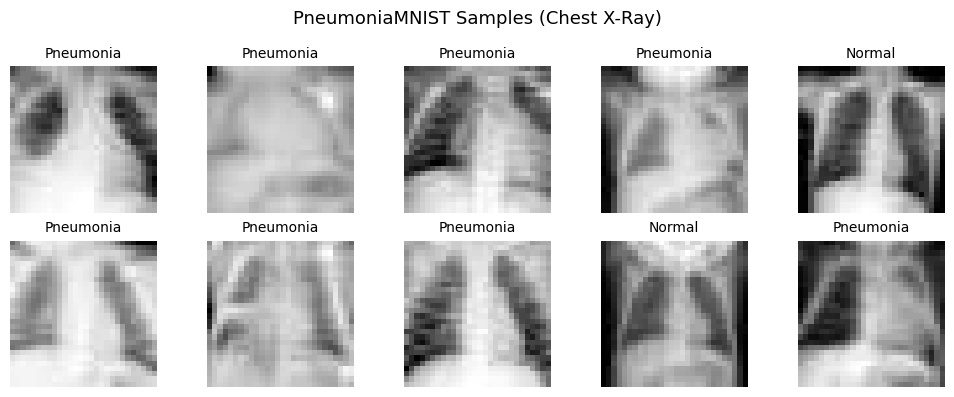


--- Fine-tune V2 | PneumoniaMNIST ---
Epoch  1 | Train Acc: 93.61% | Val Acc:   96.37% | Val Loss: 0.0877
Epoch  2 | Train Acc: 96.98% | Val Acc:   96.95% | Val Loss: 0.0791
Epoch  3 | Train Acc: 97.85% | Val Acc:   96.18% | Val Loss: 0.0870
Epoch  4 | Train Acc: 98.58% | Val Acc:   97.52% | Val Loss: 0.0768
Epoch  5 | Train Acc: 99.07% | Val Acc:   96.37% | Val Loss: 0.1042
Epoch  6 | Train Acc: 99.49% | Val Acc:   96.76% | Val Loss: 0.0956
Epoch  7 | Train Acc: 99.30% | Val Acc:   95.42% | Val Loss: 0.2103
Epoch  8 | Train Acc: 99.02% | Val Acc:   96.95% | Val Loss: 0.0914 → LR: 1.00e-03 → 5.00e-04
Epoch  9 | Train Acc: 99.94% | Val Acc:   97.33% | Val Loss: 0.0948

Early stopping at epoch 9. Best epoch: 4
Best epoch: 4  |  Best val loss: 0.0768

--- Scratch CNN | PneumoniaMNIST ---
Epoch  1 | Train Acc: 91.82% | Val Acc:   90.08% | Val Loss: 0.2284
Epoch  2 | Train Acc: 95.75% | Val Acc:   96.56% | Val Loss: 0.1266
Epoch  3 | Train Acc: 96.43% | Val Acc:   96.56% | Val Loss: 0.0781

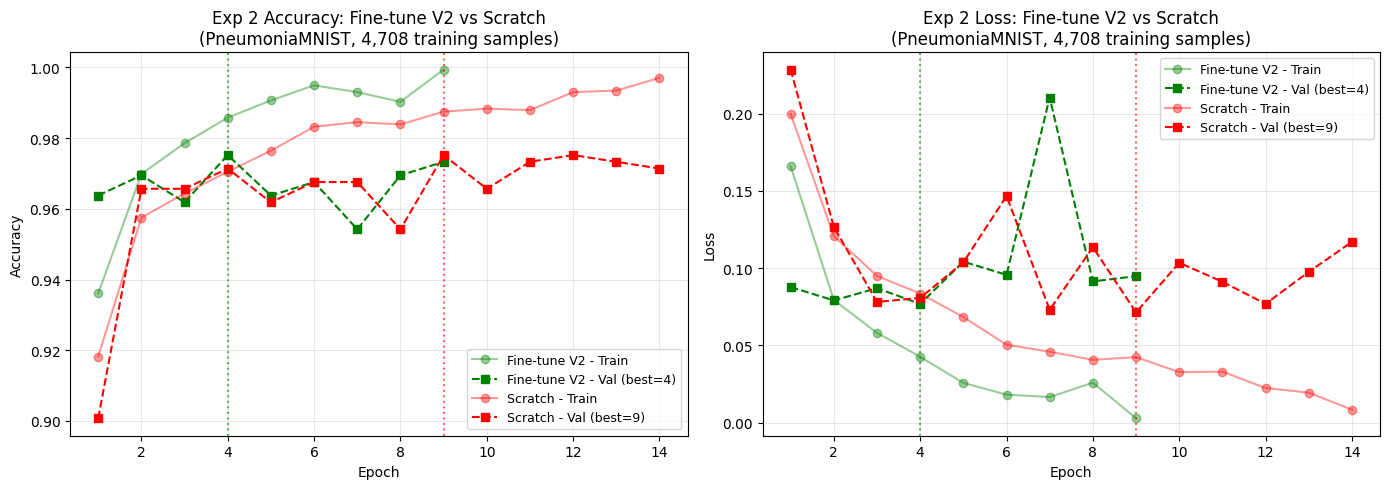

In [27]:
# ========================================================
# 實驗二：PneumoniaMNIST（含資料載入）
# ========================================================
!pip install medmnist

import medmnist
from medmnist import PneumoniaMNIST

# --- 載入 PneumoniaMNIST ---
pneumonia_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

pneumonia_train = PneumoniaMNIST(split='train', transform=pneumonia_transform, download=True)
pneumonia_val   = PneumoniaMNIST(split='val',   transform=pneumonia_transform, download=True)
pneumonia_test  = PneumoniaMNIST(split='test',  transform=pneumonia_transform, download=True)

print(f"PneumoniaMNIST — Train: {len(pneumonia_train):,} | "
      f"Val: {len(pneumonia_val):,} | Test: {len(pneumonia_test):,}")

class MedMNISTWrapper(torch.utils.data.Dataset):
    def __init__(self, medmnist_dataset):
        self.dataset = medmnist_dataset
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, int(label)

pneumonia_train_loader = DataLoader(MedMNISTWrapper(pneumonia_train), batch_size=32, shuffle=True)
pneumonia_val_loader   = DataLoader(MedMNISTWrapper(pneumonia_val),   batch_size=32, shuffle=False)
pneumonia_test_loader  = DataLoader(MedMNISTWrapper(pneumonia_test),  batch_size=32, shuffle=False)

# 視覺化樣本
pneumonia_class_names = ['Normal', 'Pneumonia']
p_images, p_labels = next(iter(pneumonia_train_loader))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()
for i in range(10):
    img = (p_images[i].squeeze() + 1) / 2
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(pneumonia_class_names[p_labels[i].item()], fontsize=10)
    axes[i].axis('off')
plt.suptitle('PneumoniaMNIST Samples (Chest X-Ray)', fontsize=13)
plt.tight_layout()
plt.show()

# 共用訓練設定（與實驗一完全相同）
SHARED_CONFIG = dict(
    num_epochs    = 30,
    learning_rate = 0.001,
    weight_decay  = 1e-4,
    patience      = 5,
    min_delta     = 1e-3,
)
loss_fn = nn.CrossEntropyLoss()

# --- Fine-tune V2（PneumoniaMNIST）---
pretrained_cnn.load_state_dict(torch.load("cnn.pt"))
ft_pneumonia = FineTuneCNN(pretrained_cnn, num_classes=2, dropout_probability=0.3)

print("\n--- Fine-tune V2 | PneumoniaMNIST ---")
(ft_p_train_losses, ft_p_train_accs,
 ft_p_val_losses,   ft_p_val_accs,
 best_ep_p) = train_with_earlystop(
    ft_pneumonia, pneumonia_train_loader, pneumonia_val_loader,
    save_path="finetune_pneumonia_best.pt",
    **SHARED_CONFIG
)

# --- Scratch CNN（PneumoniaMNIST）---
scratch_pneumonia = CNN(
    in_sizes=(28, 28), in_channels=1,
    conv1_channels=32, conv2_channels=64, conv3_channels=128,
    kernel_size=3, padding=1, pool_size=2,
    fc1_size=256, fc2_size=128, out_size=2,
    dropout_probability=0.5
)

print("\n--- Scratch CNN | PneumoniaMNIST ---")
(sc_p_train_losses, sc_p_train_accs,
 sc_p_val_losses,   sc_p_val_accs,
 best_ep_sp) = train_with_earlystop(
    scratch_pneumonia, pneumonia_train_loader, pneumonia_val_loader,
    save_path="scratch_pneumonia_best.pt",
    **SHARED_CONFIG
)

# --- 測試集評估 ---
_, acc_ft_p  = evaluate(ft_pneumonia,      pneumonia_test_loader, loss_fn)
_, acc_sc_p  = evaluate(scratch_pneumonia, pneumonia_test_loader, loss_fn)

print(f"\n{'='*62}")
print(f"【實驗二：PneumoniaMNIST（訓練集 {len(pneumonia_train):,} 張）】")
print(f"{'Model':<45} {'Best Ep':>7} {'Test Acc':>10}")
print(f"{'-'*62}")
print(f"{'Fine-tune V2 (pretrained conv)':<45} {best_ep_p:>7} {acc_ft_p*100:>9.2f}%")
print(f"{'Scratch CNN  (random init)':<45} {best_ep_sp:>7} {acc_sc_p*100:>9.2f}%")
print(f"{'Transfer advantage':<45} {'':>7} {(acc_ft_p-acc_sc_p)*100:>+9.2f}%")
print(f"{'='*62}")

# --- 學習曲線 ---
epochs_ft_p = range(1, len(ft_p_train_accs) + 1)
epochs_sc_p = range(1, len(sc_p_train_accs) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ft_p, ft_p_train_accs, 'g-o',  alpha=0.4, label='Fine-tune V2 - Train')
ax1.plot(epochs_ft_p, ft_p_val_accs,   'g--s', label=f'Fine-tune V2 - Val (best={best_ep_p})')
ax1.plot(epochs_sc_p, sc_p_train_accs, 'r-o',  alpha=0.4, label='Scratch - Train')
ax1.plot(epochs_sc_p, sc_p_val_accs,   'r--s', label=f'Scratch - Val (best={best_ep_sp})')
ax1.axvline(x=best_ep_p,  color='green', linestyle=':', alpha=0.6)
ax1.axvline(x=best_ep_sp, color='red',   linestyle=':', alpha=0.6)
ax1.set_title(f'Exp 2 Accuracy: Fine-tune V2 vs Scratch\n'
              f'(PneumoniaMNIST, {len(pneumonia_train):,} training samples)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ft_p, ft_p_train_losses, 'g-o',  alpha=0.4, label='Fine-tune V2 - Train')
ax2.plot(epochs_ft_p, ft_p_val_losses,   'g--s', label=f'Fine-tune V2 - Val (best={best_ep_p})')
ax2.plot(epochs_sc_p, sc_p_train_losses, 'r-o',  alpha=0.4, label='Scratch - Train')
ax2.plot(epochs_sc_p, sc_p_val_losses,   'r--s', label=f'Scratch - Val (best={best_ep_sp})')
ax2.axvline(x=best_ep_p,  color='green', linestyle=':', alpha=0.6)
ax2.axvline(x=best_ep_sp, color='red',   linestyle=':', alpha=0.6)
ax2.set_title(f'Exp 2 Loss: Fine-tune V2 vs Scratch\n'
              f'(PneumoniaMNIST, {len(pneumonia_train):,} training samples)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.5 低資料量實驗（KMNIST 的 10%）

在資料稀缺情境下評估遷移學習：僅使用 10% 的 KMNIST 訓練資料。這正是遷移學習優勢最顯著的場景——預訓練特徵能有效降低達到良好效能所需的標註資料量。

In [22]:
# ========================================================
# 實驗二：低資料量場景（10% KMNIST 訓練資料）
# ========================================================

# --- 建立低資料量 DataLoader（10% 訓練資料）---
total_train = len(kmnist_train_full)
low_data_size  = int(total_train * 0.1)   # ~6,000 張
discard_size   = total_train - low_data_size

low_data_subset, _ = torch.utils.data.random_split(
    kmnist_train_full,
    [low_data_size, discard_size],
    torch.Generator().manual_seed(42)
)

low_data_loader = DataLoader(low_data_subset, batch_size=64, shuffle=True)
# 驗證集與測試集維持原本的 kmnist_val_loader / kmnist_test_loader

print(f"Low-data training set size: {len(low_data_subset):,} "
      f"({len(low_data_subset)/total_train*100:.1f}% of full training set)")

# --- Fine-tune V2（低資料量）---
pretrained_cnn.load_state_dict(torch.load("cnn.pt"))
ft_low_model = FineTuneCNN(pretrained_cnn, num_classes=10, dropout_probability=0.3)

print("\n--- Fine-tune V2 | Low Data (10%) ---")
(ft_low_train_losses, ft_low_train_accs,
 ft_low_val_losses,   ft_low_val_accs,
 best_ep_low) = train_finetune_v2(
    ft_low_model, low_data_loader, kmnist_val_loader, num_epochs=20
)

# --- Scratch CNN（低資料量）---
scratch_low = CNN(
    in_sizes=(28, 28), in_channels=1,
    conv1_channels=32, conv2_channels=64, conv3_channels=128,
    kernel_size=3, padding=1, pool_size=2,
    fc1_size=256, fc2_size=128, out_size=10,
    dropout_probability=0.5
)

print("\n--- Scratch CNN | Low Data (10%) ---")
(sc_low_train_losses, sc_low_train_accs,
 sc_low_val_losses,   sc_low_val_accs) = train(
    scratch_low, low_data_loader, kmnist_val_loader,
    num_epochs=20, learning_rate=0.001
)

# --- 測試集評估 ---
_, acc_ft_low  = evaluate(ft_low_model, kmnist_test_loader, loss_fn)
_, acc_sc_low  = evaluate(scratch_low,  kmnist_test_loader, loss_fn)

print(f"\n{'='*55}")
print(f"【實驗二：低資料量（10%）】")
print(f"{'Model':<35} {'Test Acc':>10}")
print(f"{'-'*55}")
print(f"{'Fine-tune V2 (low data)':<35} {acc_ft_low*100:>9.2f}%")
print(f"{'Scratch CNN (low data)':<35} {acc_sc_low*100:>9.2f}%")
print(f"{'─ 參考：全資料 Fine-tune V2':<35} {acc_ft2*100:>9.2f}%")
print(f"{'─ 參考：全資料 Scratch':<35} {acc_scratch*100:>9.2f}%")
print(f"{'='*55}")

# --- 學習曲線 ---
epochs_ft_low = range(1, len(ft_low_train_accs) + 1)
epochs_sc_low = range(1, len(sc_low_train_accs) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ft_low, ft_low_train_accs, 'g-o',  label='Fine-tune V2 - Train')
ax1.plot(epochs_ft_low, ft_low_val_accs,   'g--s', label='Fine-tune V2 - Val')
ax1.plot(epochs_sc_low, sc_low_train_accs, 'r-o',  label='Scratch - Train')
ax1.plot(epochs_sc_low, sc_low_val_accs,   'r--s', label='Scratch - Val')
ax1.axvline(x=best_ep_low, color='gray', linestyle=':',
            label=f'Fine-tune best epoch ({best_ep_low})')
ax1.set_title('Exp 2 Accuracy: Fine-tune vs Scratch (Low Data 10%)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ft_low, ft_low_train_losses, 'g-o',  label='Fine-tune V2 - Train')
ax2.plot(epochs_ft_low, ft_low_val_losses,   'g--s', label='Fine-tune V2 - Val')
ax2.plot(epochs_sc_low, sc_low_train_losses, 'r-o',  label='Scratch - Train')
ax2.plot(epochs_sc_low, sc_low_val_losses,   'r--s', label='Scratch - Val')
ax2.axvline(x=best_ep_low, color='gray', linestyle=':',
            label=f'Fine-tune best epoch ({best_ep_low})')
ax2.set_title('Exp 2 Loss: Fine-tune vs Scratch (Low Data 10%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Low-data training set size: 6,000 (10.0% of full training set)

--- Fine-tune V2 | Low Data (10%) ---
Epoch  1 | Train Acc: 69.62% | Val Acc: 88.90% | Val Loss: 0.3703
Epoch  2 | Train Acc: 92.08% | Val Acc: 92.58% | Val Loss: 0.2422
Epoch  3 | Train Acc: 95.67% | Val Acc: 93.46% | Val Loss: 0.2153
Epoch  4 | Train Acc: 97.23% | Val Acc: 94.08% | Val Loss: 0.2093
Epoch  5 | Train Acc: 98.17% | Val Acc: 94.80% | Val Loss: 0.1871
Epoch  6 | Train Acc: 99.00% | Val Acc: 94.83% | Val Loss: 0.1862
Epoch  7 | Train Acc: 99.33% | Val Acc: 95.20% | Val Loss: 0.1875
Epoch  8 | Train Acc: 99.47% | Val Acc: 94.76% | Val Loss: 0.2003
Epoch  9 | Train Acc: 99.57% | Val Acc: 94.67% | Val Loss: 0.2037
Epoch 10 | Train Acc: 99.70% | Val Acc: 95.19% | Val Loss: 0.1987 → LR: 1.00e-04 → 5.00e-05
Epoch 11 | Train Acc: 99.78% | Val Acc: 95.33% | Val Loss: 0.1905

Early stopping at epoch 11. Best epoch: 6

Best epoch: 6  |  Best val loss: 0.1862

--- Scratch CNN | Low Data (10%) ---

【實驗二：低資料量（10%）】
Model  

NameError: name 'acc_ft2' is not defined

## 10. 模型可解釋性

從兩個互補角度分析 CNN 學到了什麼：

1. **混淆矩陣** — 使用遷移學習模型對 KMNIST 測試集進行逐類別錯誤分析
2. **第一層卷積濾波器視覺化** — 顯示第一個卷積層學到的 32 個 3×3 濾波器，揭示網路在 Fashion MNIST 預訓練階段習得、並在遷移後保留的低階邊緣與紋理偵測器。

c:\Users\tonykuo\PycharmProjects\JupyterProject\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\tonykuo\PycharmProjects\JupyterProject\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12365 (\N{HIRAGANA LETTER KI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\tonykuo\PycharmProjects\JupyterProject\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12377 (\N{HIRAGANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\tonykuo\PycharmProjects\JupyterProject\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12388 (\N{HIRAGANA LETTER TU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\tonykuo\PycharmProjects\JupyterProject\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\tonykuo

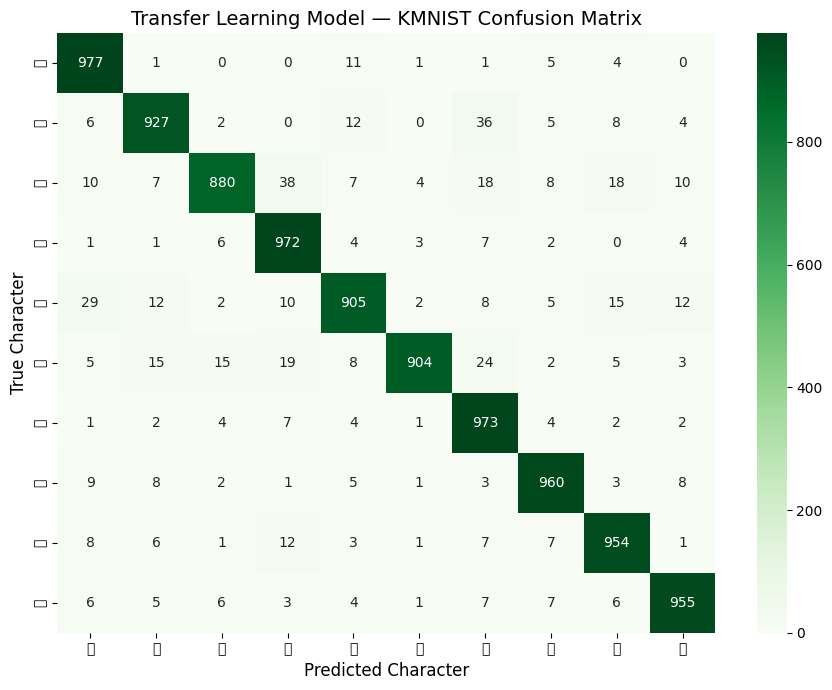


Transfer Learning Model — Classification Report:
              precision    recall  f1-score   support

           お       0.93      0.98      0.95      1000
           き       0.94      0.93      0.93      1000
           す       0.96      0.88      0.92      1000
           つ       0.92      0.97      0.94      1000
           な       0.94      0.91      0.92      1000
           は       0.98      0.90      0.94      1000
           ま       0.90      0.97      0.93      1000
           や       0.96      0.96      0.96      1000
           れ       0.94      0.95      0.95      1000
           を       0.96      0.95      0.96      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



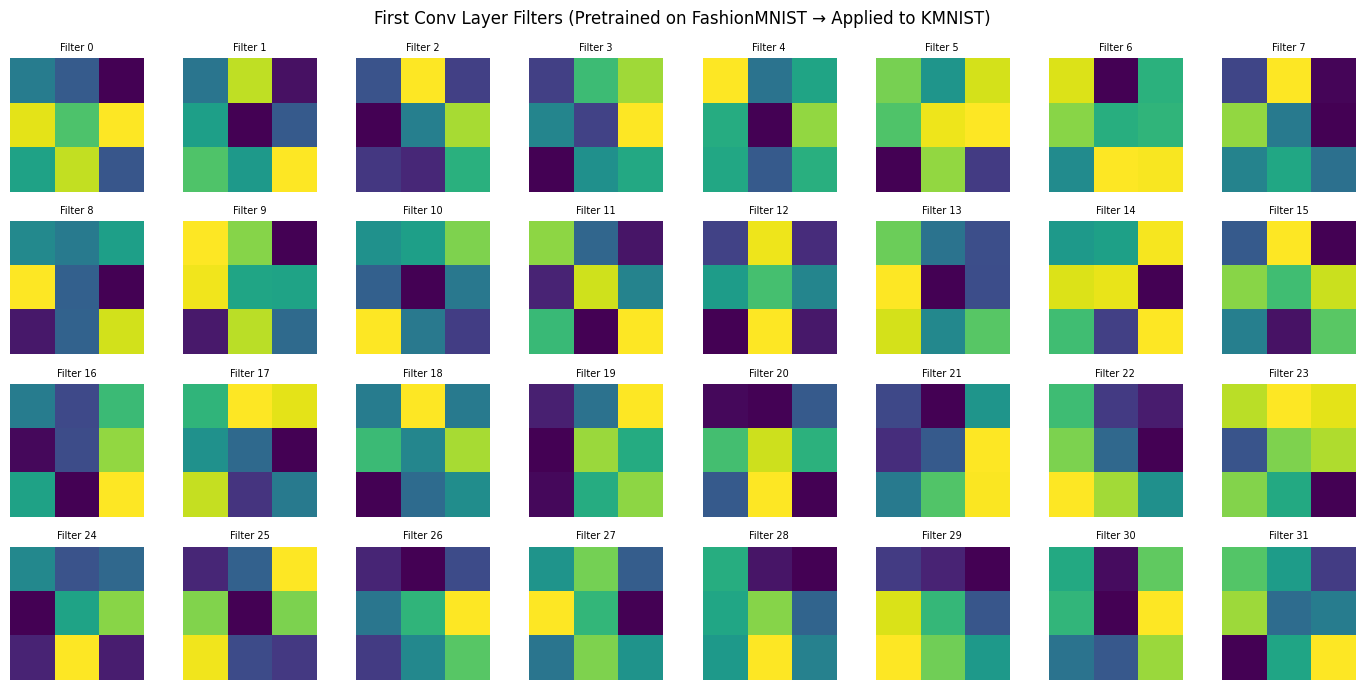

In [14]:
# --- 遷移學習模型在 KMNIST 上的混淆矩陣 ---
transfer_preds_k, transfer_labels_k = [], []
transfer_model.eval()
with torch.no_grad():
    for images, labels in kmnist_test_loader:
        outputs = transfer_model(images)
        preds   = outputs.argmax(dim=1)
        transfer_preds_k.extend(preds.numpy())
        transfer_labels_k.extend(labels.numpy())

transfer_preds_k  = np.array(transfer_preds_k)
transfer_labels_k = np.array(transfer_labels_k)

cm_transfer = confusion_matrix(transfer_labels_k, transfer_preds_k)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Greens',
            xticklabels=kmnist_class_names,
            yticklabels=kmnist_class_names, ax=ax)
ax.set_xlabel('Predicted Character', fontsize=12)
ax.set_ylabel('True Character',      fontsize=12)
ax.set_title('Transfer Learning Model — KMNIST Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTransfer Learning Model — Classification Report:")
print(classification_report(transfer_labels_k, transfer_preds_k,
                             target_names=kmnist_class_names))

# --- 視覺化第一層卷積濾波器 ---
first_conv_weights = transfer_model.convolution_layers[0].weight.data.clone()

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
axes = axes.flatten()
for i in range(32):
    axes[i].imshow(first_conv_weights[i, 0], cmap='viridis')
    axes[i].set_title(f'Filter {i}', fontsize=7)
    axes[i].axis('off')

plt.suptitle('First Conv Layer Filters (Pretrained on FashionMNIST → Applied to KMNIST)',
             fontsize=12)
plt.tight_layout()
plt.show()